# Spike shape press figure, components

Building blocks for a press illustration of "different spike shapes from the same neuron",
aimed at a 3 row by 2 column layout:

- **Row 1, pvc-6, Cell 1**: mean waveform by pink noise input amplitude (most extreme 15% by
  pre-spike input strength, 200 ms window). This is the only pvc-6 option kept: by-stim-type
  comparisons were dropped since the effect is too subtle to be visual (checked: constant vs.
  ramp vs. pink, ramp vs. pink alone, individual spikes, and Cell 2, all only showed a small
  difference).
- **Row 2, spe-1**: mean waveform by spontaneous cluster. Cell 21 (peak amplitude, Low/Mid/High)
  and Cell 19 (decay rate, two-way split) as two different illustrations of spontaneous
  waveform variability.
- **Row 3, spe-1**: mean waveform by surrounding LFP amplitude. Cell 3 (strongest individual
  relationship, CV R^2 = 0.64) and Cell 1 (second-strongest, CV R^2 = 0.43), each with both
  an all-spikes and a shaded mean-and-SD version.

Each panel is built and plotted separately below, pick and combine for the final figure.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import sys, os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator
from IPython.display import display

sys.path.append('../../datasets/pvc-6/pvc6_helper_modules/')
sys.path.append('../../datasets/spe-1/spe1_helper_modules/')
import config

sns.set_style('ticks')
plt.rcParams.update({
    'font.size': 15, 'axes.titlesize': 15, 'axes.labelsize': 16,
    'xtick.labelsize': 13, 'ytick.labelsize': 13, 'legend.fontsize': 12,
    'figure.dpi': 150,
})

CACHE_DIR = 'press_fig_cache'
os.makedirs(CACHE_DIR, exist_ok=True)
FORCE_RERUN = False

# Shared quality filter used everywhere in this notebook: percentile-based (not an
# absolute R^2), since typical fit quality differs a lot by dataset -- pvc-6 fits are
# almost all excellent (median R^2 ~0.97-1.0) while spe-1 fits are much noisier
# (median ramp R^2 ~0.15, Supp Fig 2), so a fixed threshold tuned for one dataset would
# either do nothing or throw out nearly everything in the other.
QUALITY_PCTL = 50


def style_press_ax(ax, legend=True, n_xticks=5, n_yticks=4, legend_fontsize=26,
                    title_fontsize=24):
    """Shared press-figure styling: bigger fonts, fewer ticks, bold axis labels, thick
    spines. If a legend exists, it's built as a completely separate Figure (not just a
    separate Axes) and returned -- never overlapping or sharing canvas with the data,
    matching the house rules used across the paper's supp figures. Text sizes are set
    noticeably large relative to the waveform lines, for a press/media audience."""
    ax.xaxis.label.set_fontsize(30)
    ax.xaxis.label.set_fontweight('bold')
    ax.yaxis.label.set_fontsize(30)
    ax.yaxis.label.set_fontweight('bold')
    ax.tick_params(labelsize=24)
    if ax.get_title():
        ax.title.set_fontsize(title_fontsize)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=n_xticks))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=n_yticks))
    for spine in ax.spines.values():
        spine.set_linewidth(1.4)
    sns.despine(ax=ax)

    fig_legend = None
    if legend:
        handles, labels = ax.get_legend_handles_labels()
        if handles:
            # a completely separate Figure, not a subplot/axes of the data figure -- it
            # needs its own (invisible) axes, otherwise IPython's inline-display code
            # treats a 0-axes figure as "empty" and silently skips rendering it.
            fig_legend = plt.figure(figsize=(len(handles) * 4, 1.5))
            ax_legend = fig_legend.add_axes([0, 0, 1, 1])
            ax_legend.axis('off')
            fig_legend.legend(handles, labels, ncol=len(handles), loc='center',
                               frameon=False, fontsize=legend_fontsize)
    return fig_legend


def show_and_close(*figs):
    """Display each figure explicitly, then close it -- otherwise the inline backend's
    end-of-cell auto-display would render every one of them a second time."""
    for fig in figs:
        if fig is not None:
            display(fig)
            plt.close(fig)

## Row 1, pvc-6, Cell 1: waveform by pink noise input amplitude

In [2]:
# Refit Cell 1 (reuses the same cached df_stim_features/all_data pickles the main
# pvc6 notebook uses, so this does NOT need the raw .h5 file). Cached locally after
# first run so this cell is fast on repeat.
PVC6_PICKLE_DIR = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/pvc6_pickles/'
_raw_cache = os.path.join(CACHE_DIR, 'pvc6_c1_raw.pkl')

if not FORCE_RERUN and os.path.exists(_raw_cache):
    with open(_raw_cache, 'rb') as f:
        pvc6_raw = pickle.load(f)
    print('Loaded cached pvc6_raw:', pvc6_raw['spikes'].shape)
else:
    from spikewise.patch.fit import Spike
    from spikewise.patch.window import window_spike
    with open(PVC6_PICKLE_DIR + 'all_data.pkl', 'rb') as f:
        all_data = pickle.load(f)
    all_data_flat = [spike for sweep in all_data for spike in sweep]
    with open(PVC6_PICKLE_DIR + 'df_stim_features.pkl', 'rb') as f:
        df_stim_features = pickle.load(f)

    fs = 200000
    sp = Spike(thresh_amp=-10, window_length=(5., 5.), smooth_frac=.008, pre_inflection_ms=0.5)
    sp.fit(all_data_flat, fs, n_jobs=-1)
    # r_squared_ramp/exp are dropped from df_features by filter_features() (default
    # drop_r_squared=True), but survive as attributes on sp itself, filtered in step.
    sp.filter_features()
    df = pd.concat([df_stim_features, sp.df_features], axis=1).dropna(subset=['stim_type'])

    # The +/-5ms window used for feature fitting is too short to show the full
    # after-hyperpolarization (AHP) recovering back toward baseline -- re-window a wider
    # display-only version (same peak reference, same underlying raw signal) so plots
    # don't cut off mid-recovery and look like a persistent, unrecovered baseline shift.
    peak_inds = sp.df_indices['peak'].to_numpy().astype(int)
    sig_flat = np.asarray(all_data_flat)
    spikes_wide = window_spike(sig_flat, fs, peak_inds, window_length=(5., 20.))

    pvc6_raw = {
        'spikes': sp.spikes,
        'spikes_wide': spikes_wide,
        'wide_pre_ms': 5.,
        'wide_post_ms': 20.,
        'stim_type': df['stim_type'].to_numpy(),
        'stim_mean': df['stim_mean'].to_numpy(),
        'r_squared_ramp': sp.r_squared_ramp,
        'r_squared_exp': sp.r_squared_exp,
        'fs': fs,
        'pre_ms': sp.window_length[0],
        'post_ms': sp.window_length[1],
    }
    with open(_raw_cache, 'wb') as f:
        pickle.dump(pvc6_raw, f)
    print('Computed and cached pvc6_raw:', pvc6_raw['spikes'].shape)

Loaded cached pvc6_raw: (820, 2001)


In [3]:
t_pvc6 = np.linspace(-pvc6_raw['pre_ms'], pvc6_raw['post_ms'], pvc6_raw['spikes'].shape[1])
stim_type = pvc6_raw['stim_type']
spikes = pvc6_raw['spikes']
quality = np.minimum(pvc6_raw['r_squared_ramp'], pvc6_raw['r_squared_exp'])

### Pink noise only, extreme input-strength groups

The most visual pvc-6 option: compares the most extreme 15% of pink-noise trials by
pre-spike input strength (the 200 ms window, matching the paper's actual R^2 = 0.72 result),
using the "all quality-passing spikes overlaid, plus the mean" style below, and a shaded
mean-and-SD version after it.

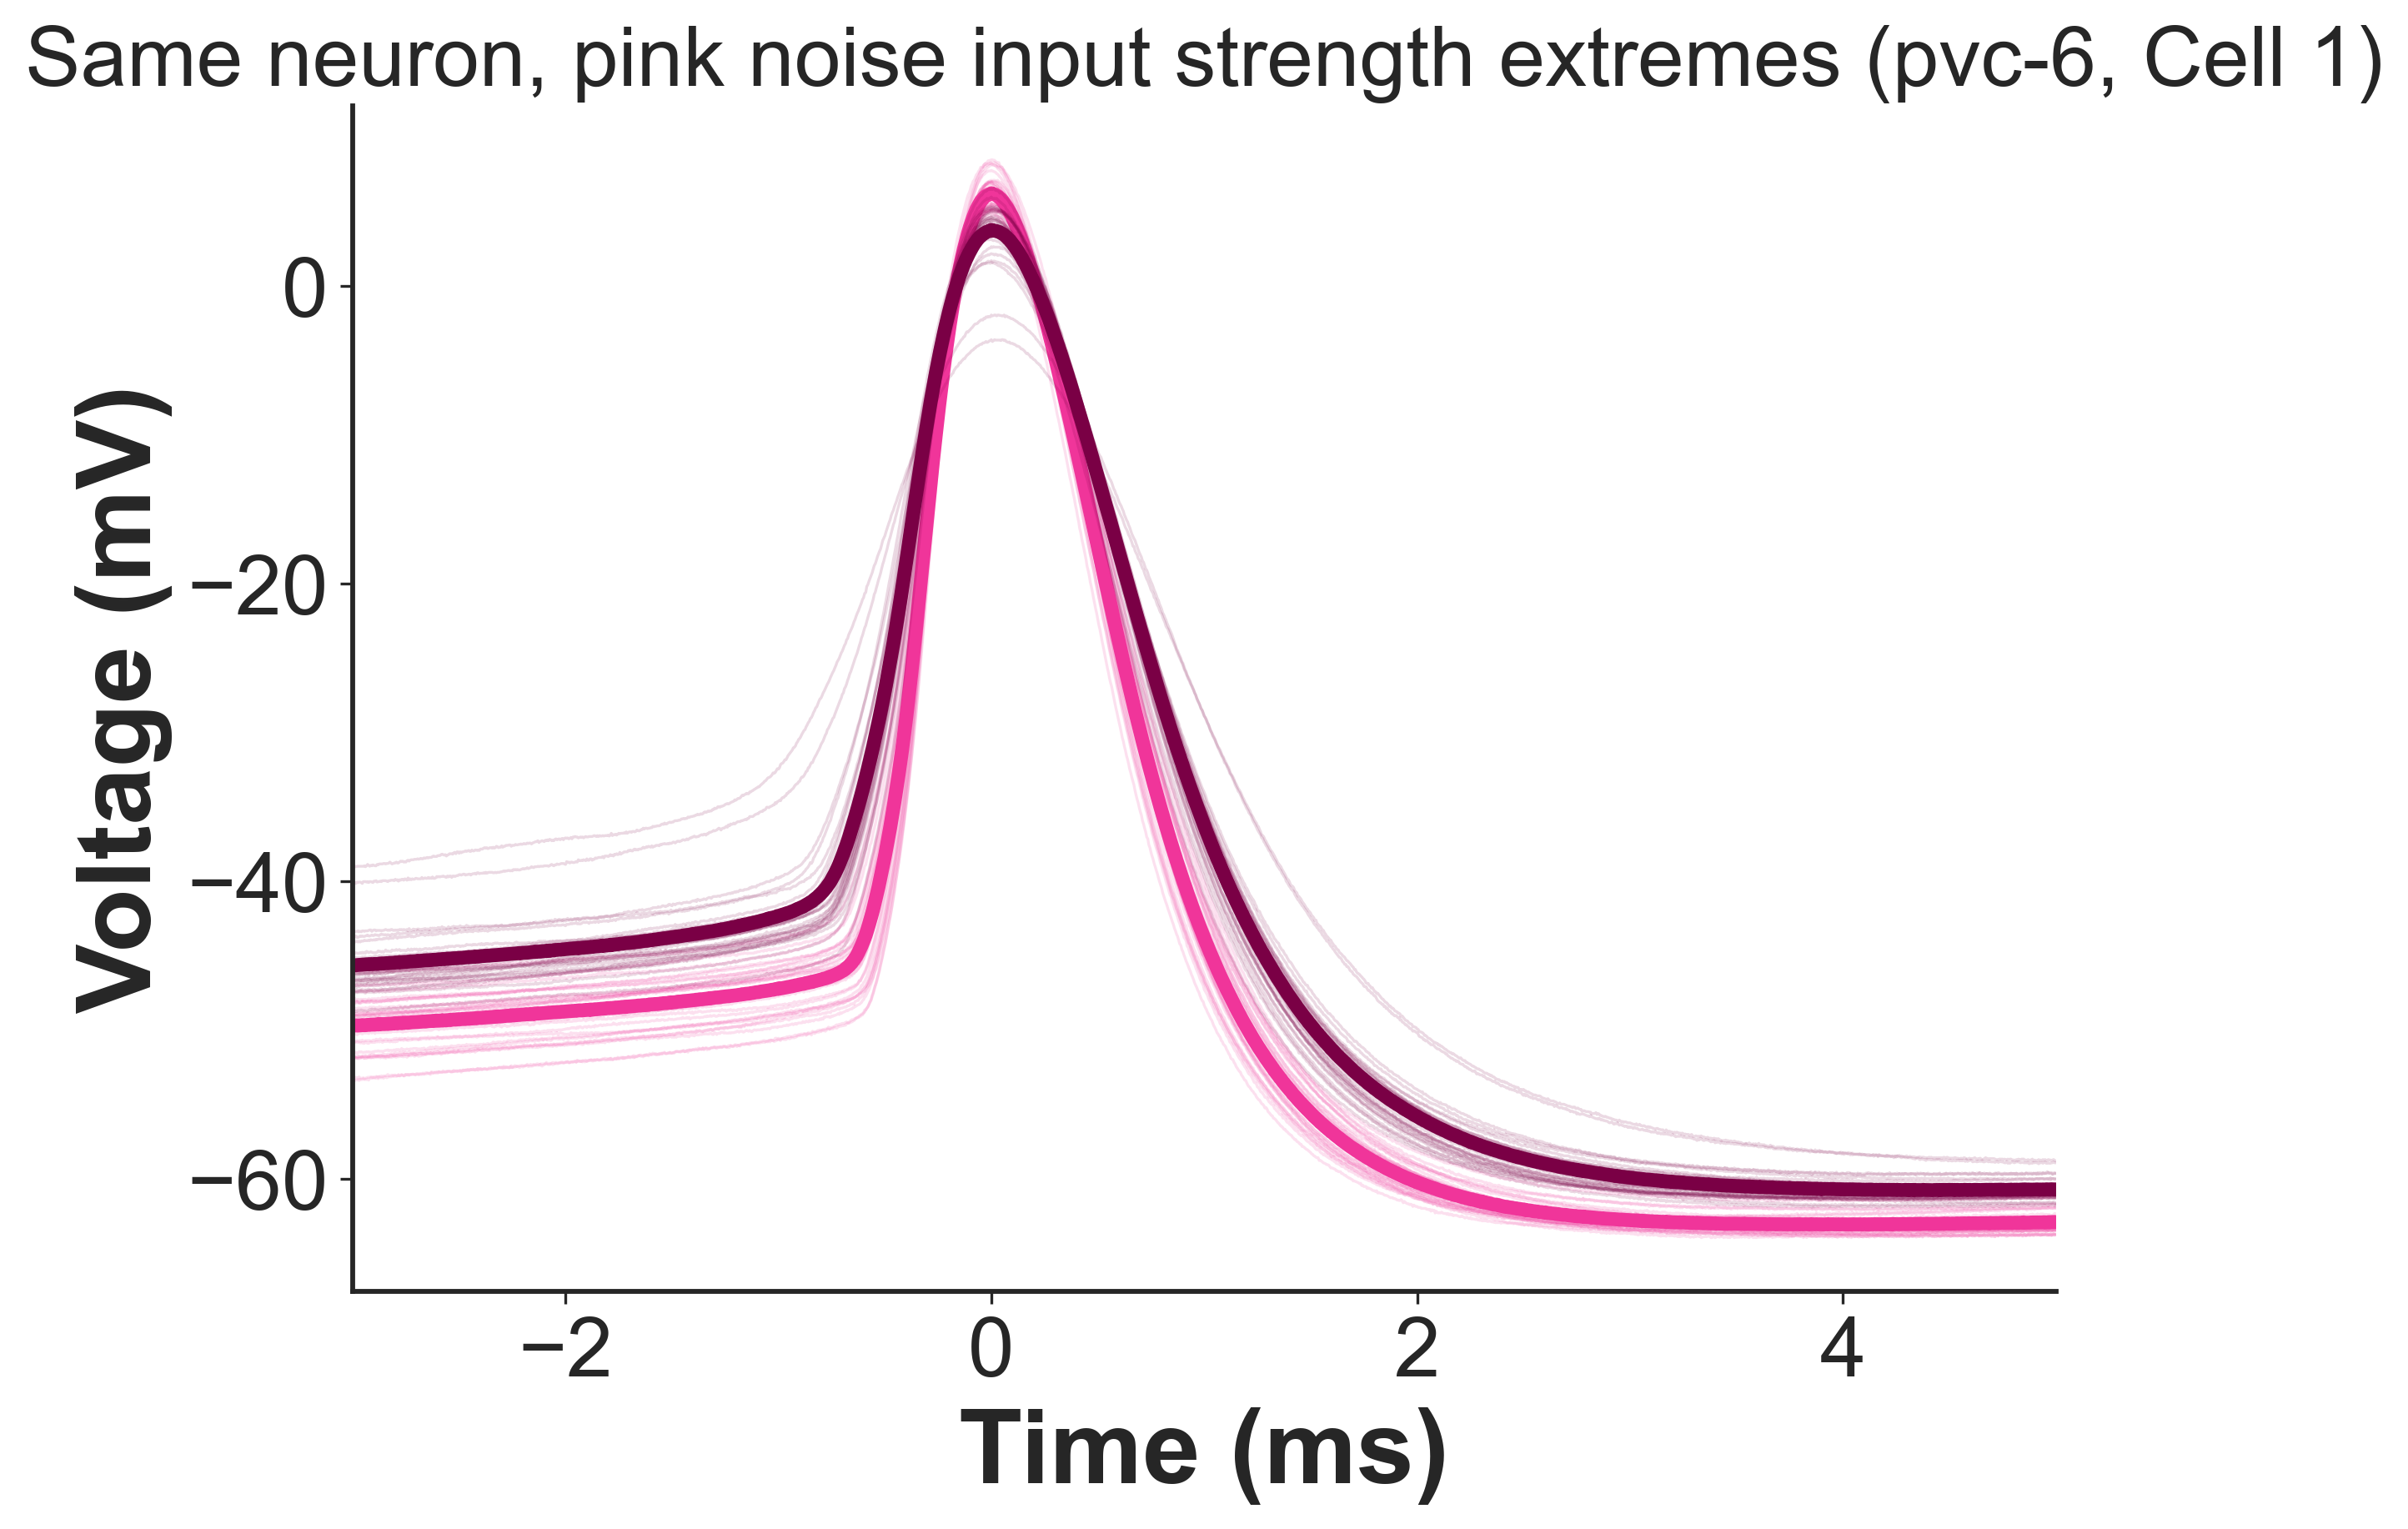

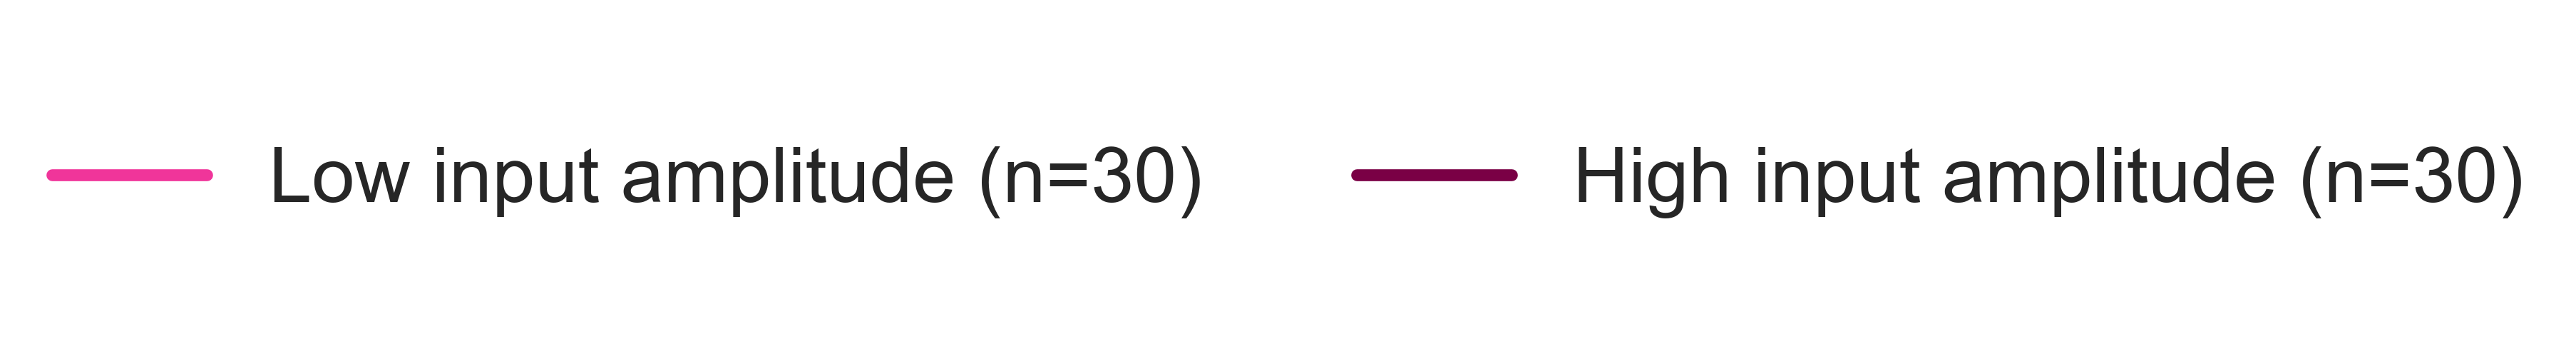

In [11]:
EXTREME_PCTL = 15  # bottom/top this-many percent of pink-noise stim_mean

# stim_mean in df_stim_features.pkl uses a 5 ms pre-inflection window (hardcoded in
# process_sweeps), NOT the 200 ms window the paper's main result (Fig 3F: R^2 = 0.72) is
# actually based on. That 200 ms version is a separately cached, index-aligned table.
with open('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/pvc6_pickles/_stim_extra_200ms.pkl', 'rb') as f:
    stim_200 = pickle.load(f)
stim_mean_200 = stim_200['stim_mean_200ms']

lo_cut, hi_cut = np.percentile(stim_mean_200, [EXTREME_PCTL, 100 - EXTREME_PCTL])
n_total = len(spikes)
EXTREME_GROUPS = {
    'weak': np.zeros(n_total, dtype=bool),
    'strong': np.zeros(n_total, dtype=bool),
}
EXTREME_GROUPS['weak'][stim_mean_200.index[stim_mean_200 <= lo_cut].to_numpy()] = True
EXTREME_GROUPS['strong'][stim_mean_200.index[stim_mean_200 >= hi_cut].to_numpy()] = True

EXTREME_COLORS = {'weak': '#F0359A', 'strong': '#7A0045'}  # saturated medium pink vs. dark
EXTREME_LABELS = {'weak': 'Low input amplitude', 'strong': 'High input amplitude'}  # magenta: still visible on white, not pastel/washed out

fig1c, ax1c = plt.subplots(figsize=(8, 6), constrained_layout=True)
for grp in ['weak', 'strong']:
    grp_idx = np.where(EXTREME_GROUPS[grp])[0]
    quality_cut = np.percentile(quality[grp_idx], QUALITY_PCTL)
    idx = grp_idx[quality[grp_idx] >= quality_cut]
    for i in idx:
        ax1c.plot(t_pvc6, spikes[i], color=EXTREME_COLORS[grp], lw=0.8, alpha=0.15)
    ax1c.plot(t_pvc6, np.nanmean(spikes[idx], axis=0), color=EXTREME_COLORS[grp], lw=4,
              label=f'{EXTREME_LABELS[grp]} (n={len(idx)})')
ax1c.set_xlim(-3, 5)
ax1c.set_xlabel('Time (ms)')
ax1c.set_ylabel('Voltage (mV)')
ax1c.set_title('Same neuron, pink noise input strength extremes (pvc-6, Cell 1)')
fig1c_legend = style_press_ax(ax1c)
show_and_close(fig1c, fig1c_legend)

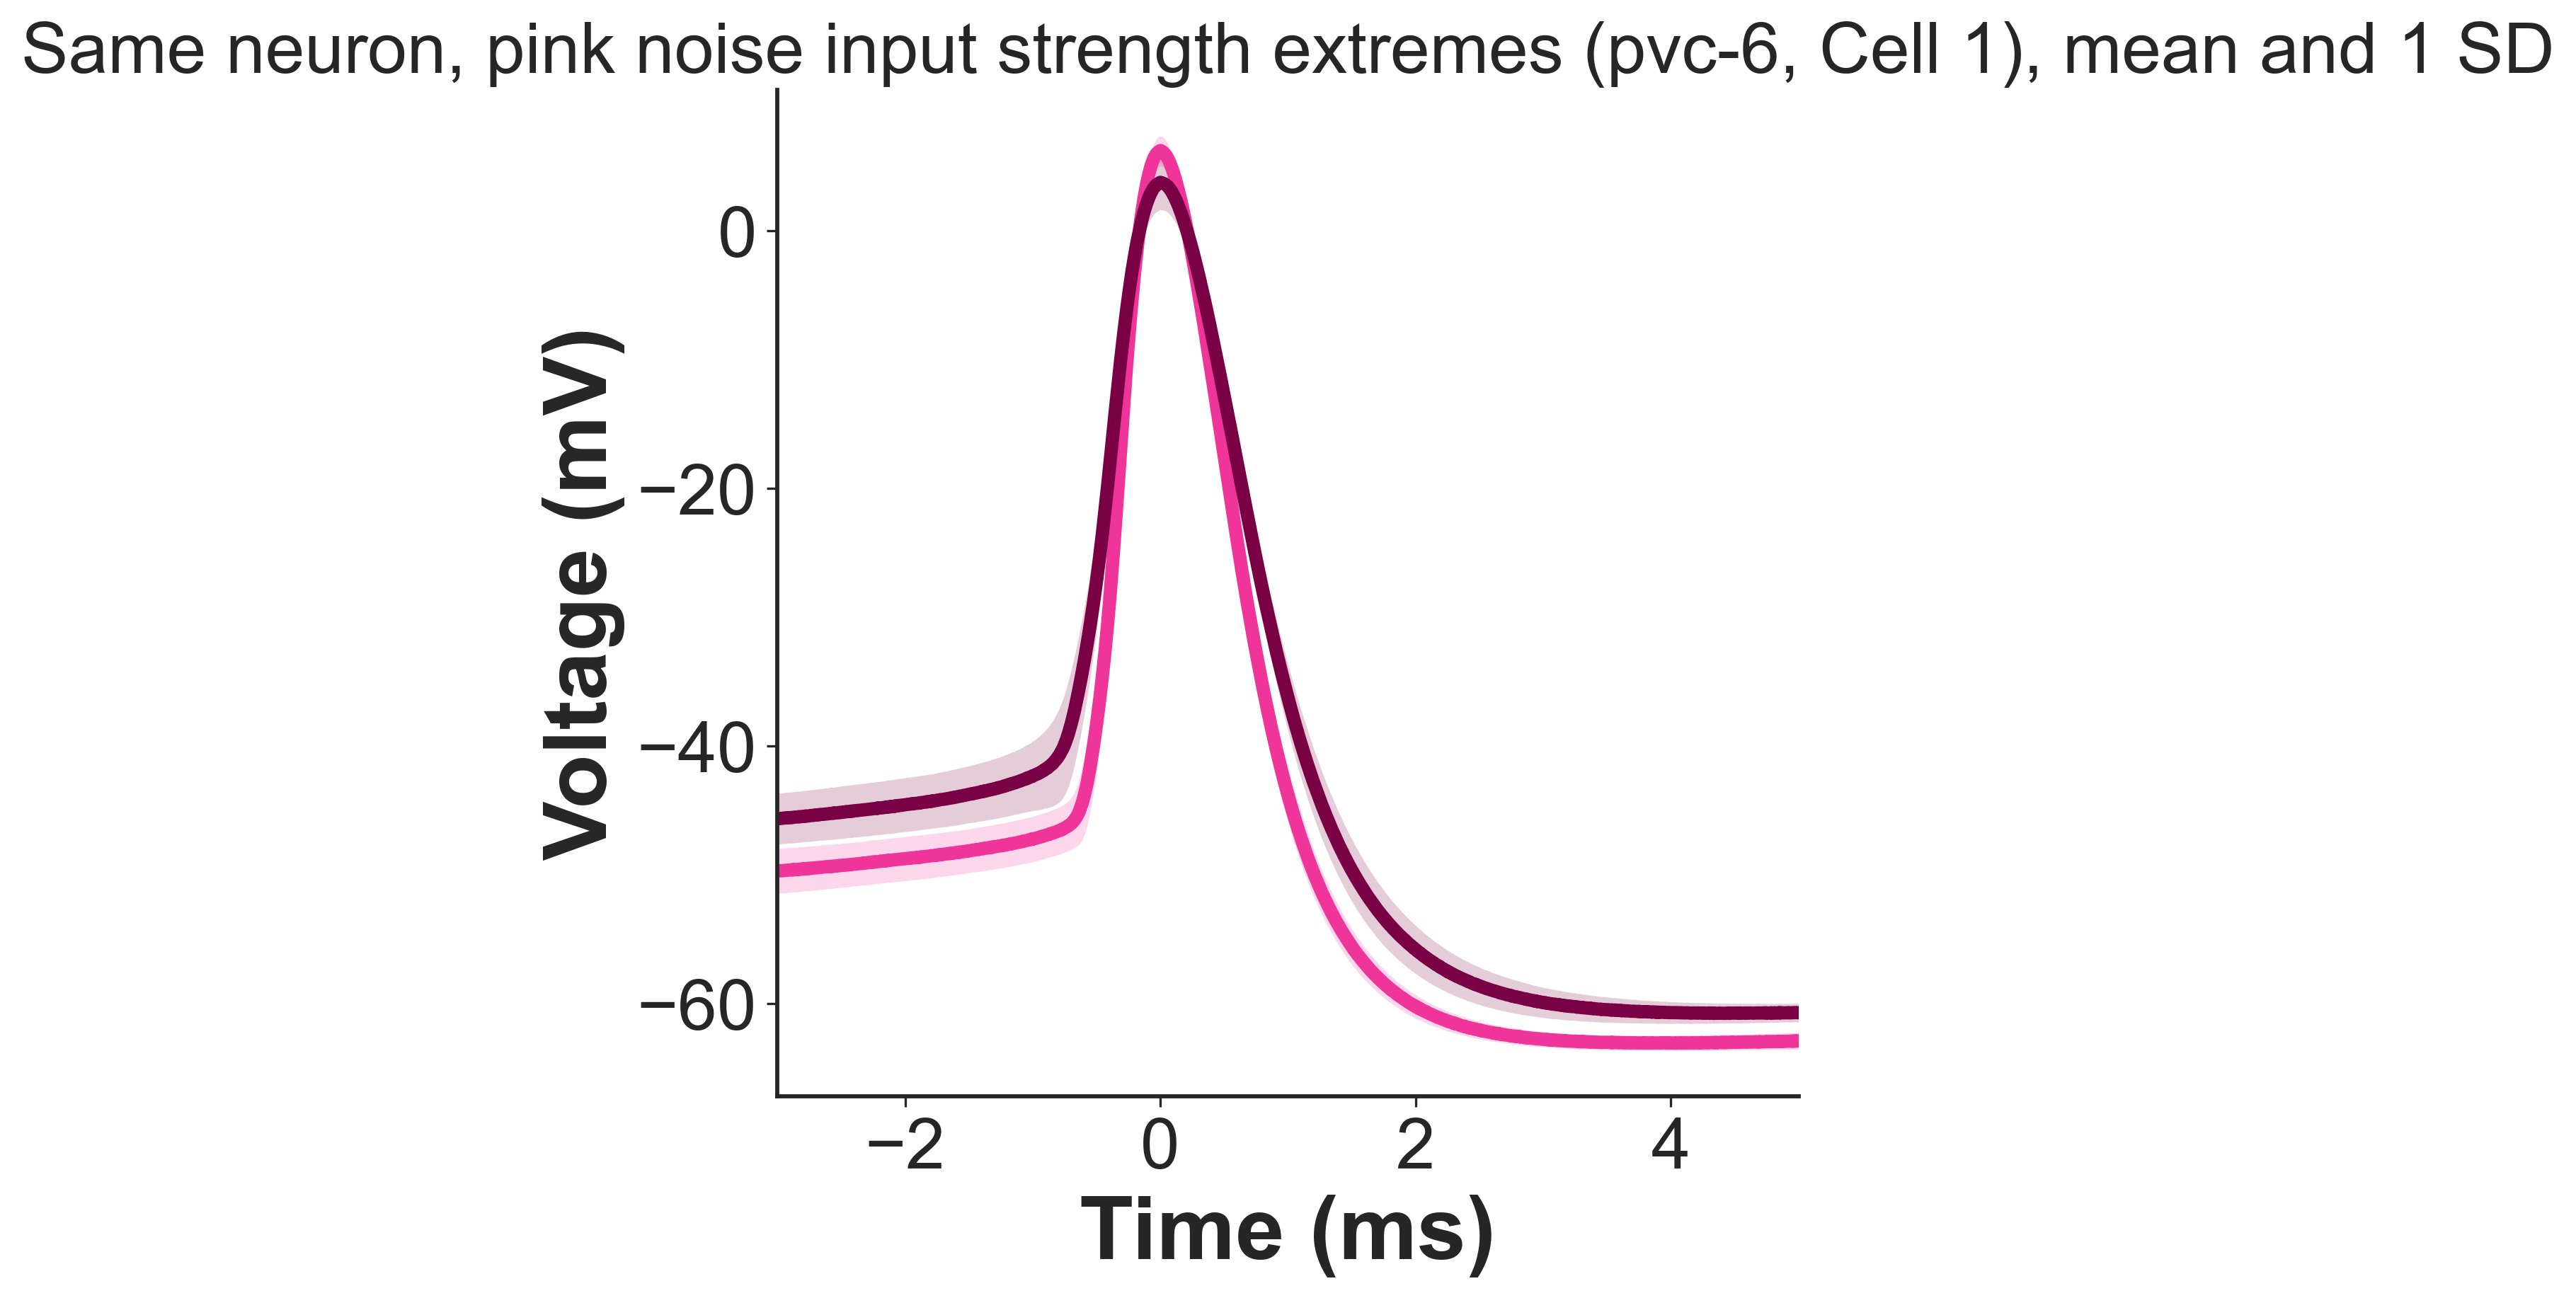

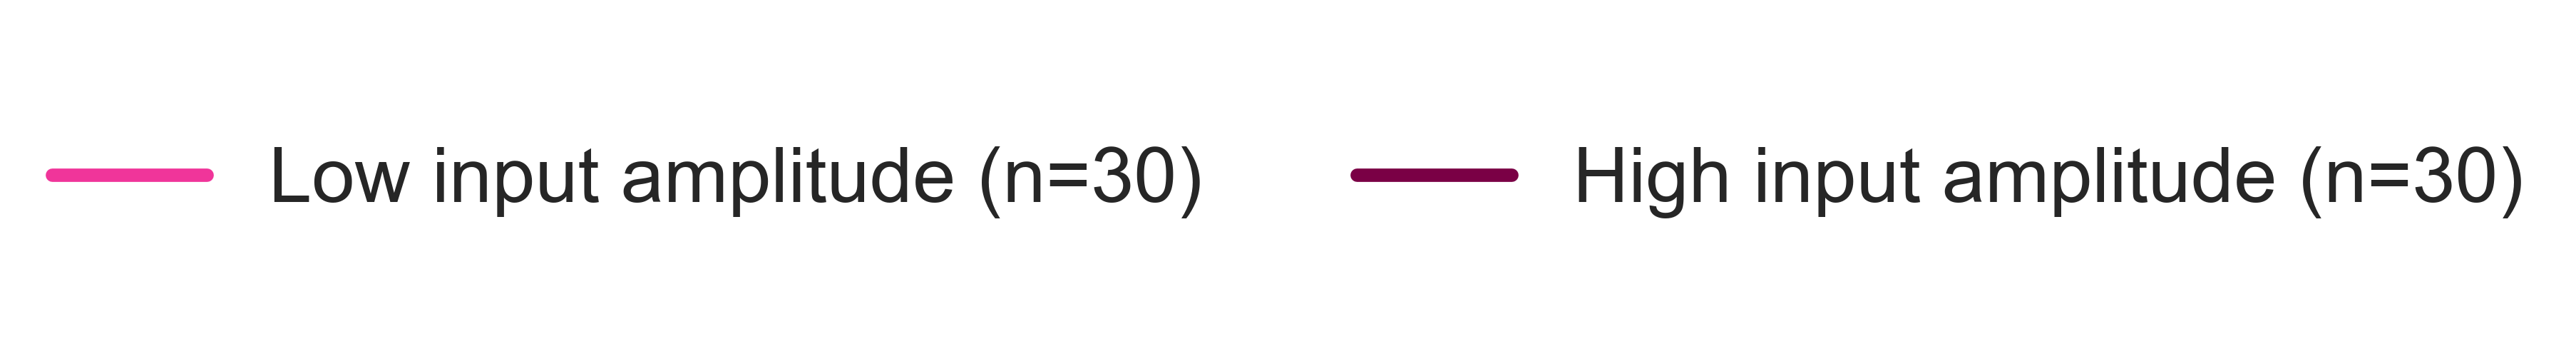

In [13]:
fig1d, ax1d = plt.subplots(figsize=(6, 6), constrained_layout=True)
for grp in ['weak', 'strong']:
    grp_idx = np.where(EXTREME_GROUPS[grp])[0]
    quality_cut = np.percentile(quality[grp_idx], QUALITY_PCTL)
    idx = grp_idx[quality[grp_idx] >= quality_cut]
    wf = spikes[idx]
    m = wf.mean(axis=0)
    s = wf.std(axis=0)
    ax1d.fill_between(t_pvc6, m - s, m + s, color=EXTREME_COLORS[grp], alpha=0.2, lw=0)
    ax1d.plot(t_pvc6, m, color=EXTREME_COLORS[grp], lw=4.5, label=f'{EXTREME_LABELS[grp]} (n={len(idx)})')
ax1d.set_xlim(-3, 5)
ax1d.set_xlabel('Time (ms)')
ax1d.set_ylabel('Voltage (mV)')
ax1d.set_title('Same neuron, pink noise input strength extremes (pvc-6, Cell 1), mean and 1 SD')
fig1d_legend = style_press_ax(ax1d)
show_and_close(fig1d, fig1d_legend)

## Row 2, spe-1, Cell 21: waveform by spontaneous peak-amplitude cluster

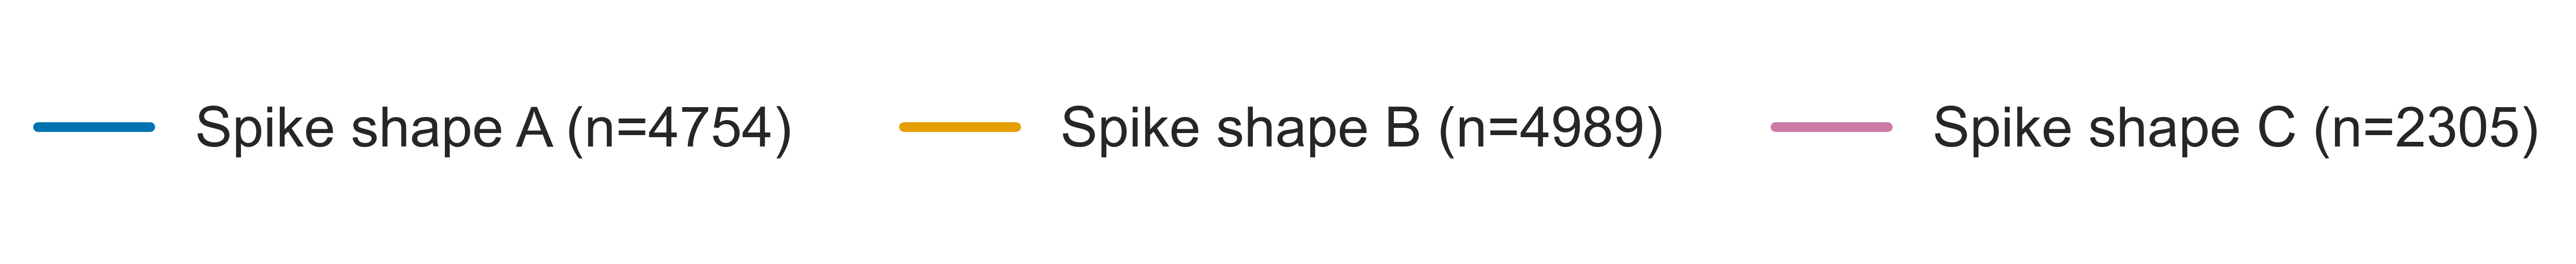

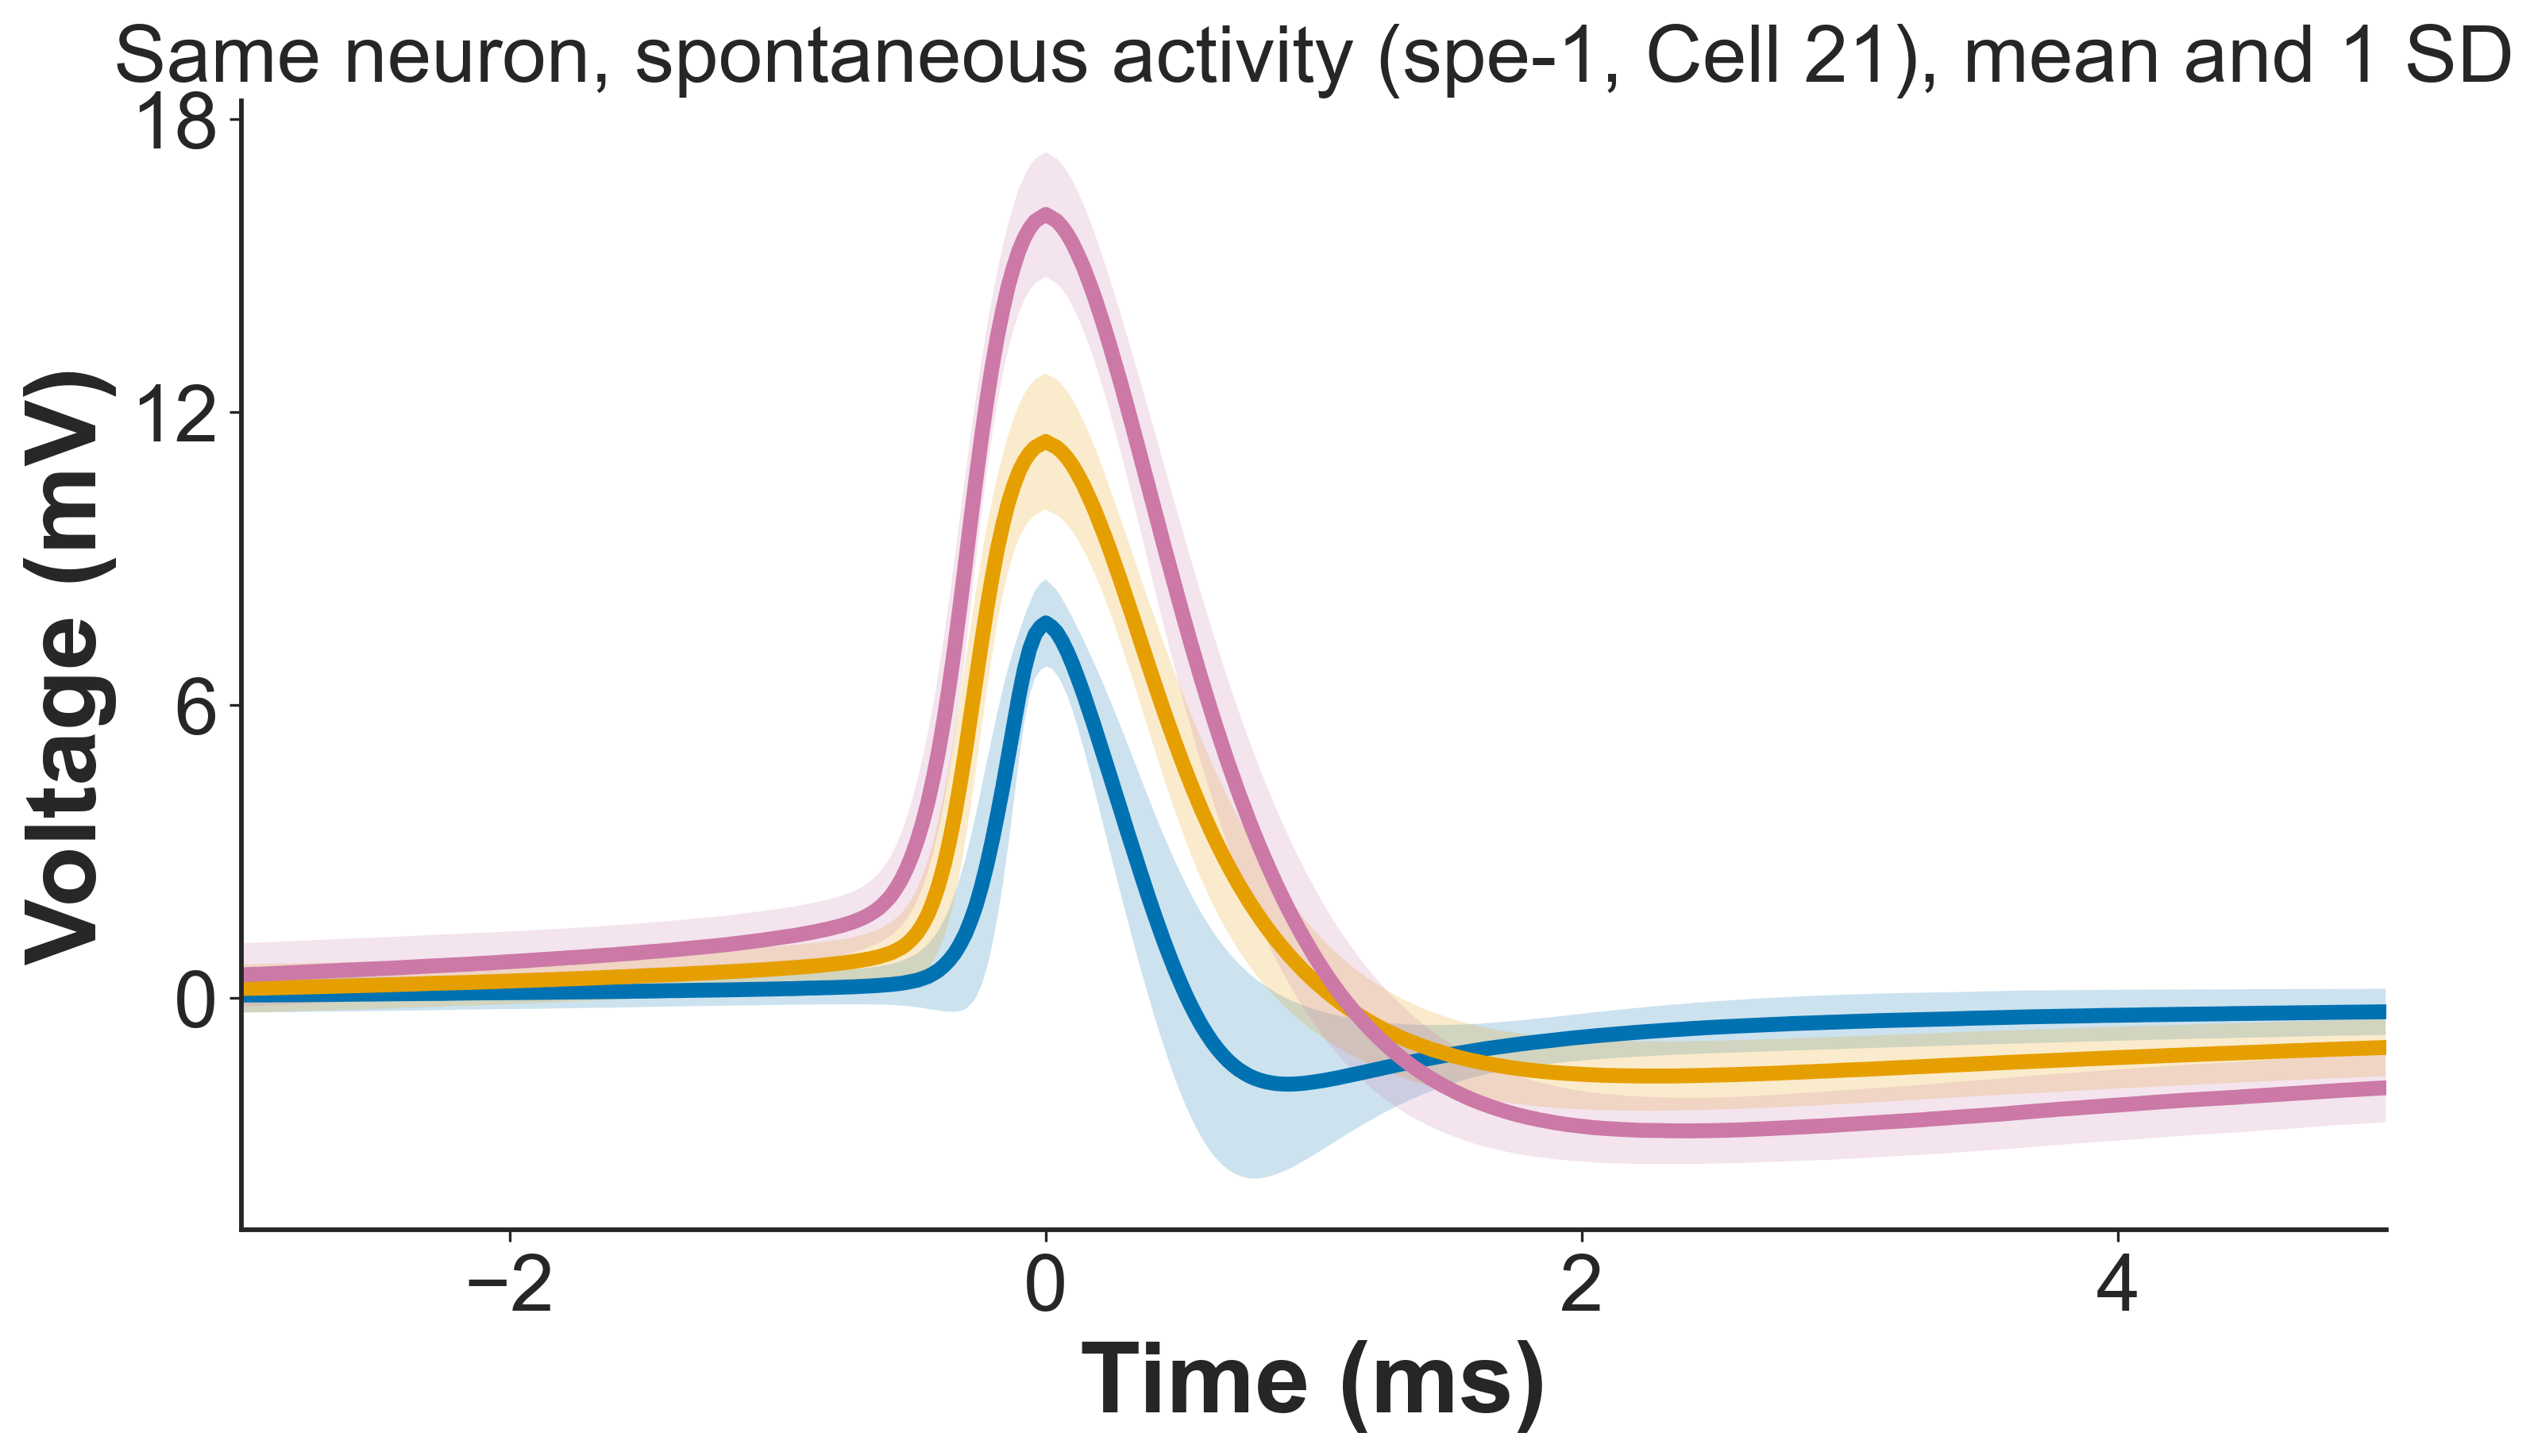

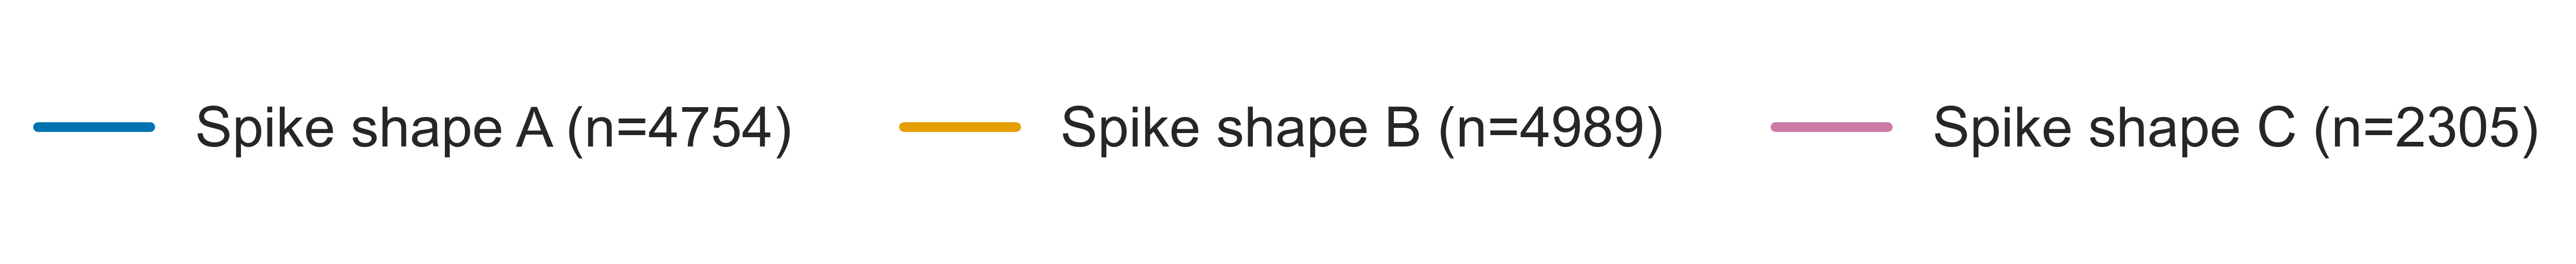

In [6]:
CLUSTER_PKL_DIR = config.SPE1_PICKLE_ROOT + '/cluster_pickles/'
with open(os.path.join(CLUSTER_PKL_DIR, 'c21_cluster_waveforms.pkl'), 'rb') as f:
    spe1_wf = pickle.load(f)['peak_amp_cluster']

fs_spe1 = config.DICT_PATCH_FS[21]
t_spe1 = spe1_wf['t_axis'] / fs_spe1 * 1000.0  # t_axis is stored in samples-from-peak

SPE1_COLORS = {'low': '#0072B2', 'mid': '#E69F00', 'high': '#CC79A7'}  # matches Fig 4B/C, Supp Fig 7-11
SPE1_LABELS = {'low': 'Spike shape A', 'mid': 'Spike shape B', 'high': 'Spike shape C'}

fig2, ax2 = plt.subplots(figsize=(10, 6), constrained_layout=True)
for k in ['low', 'mid', 'high']:
    m = spe1_wf[k]['mean']
    s = spe1_wf[k]['std']
    ax2.fill_between(t_spe1, m - s, m + s, color=SPE1_COLORS[k], alpha=0.2, lw=0)
    ax2.plot(t_spe1, m, color=SPE1_COLORS[k], lw=4.5, label=f"{SPE1_LABELS[k]} (n={spe1_wf[k]['n']})")
ax2.set_xlim(-3, 5)
ax2.set_xlabel('Time (ms)')
ax2.set_ylabel('Voltage (mV)')
ax2.set_title('Same neuron, spontaneous activity (spe-1, Cell 21), mean and 1 SD', fontsize=14)
style_press_ax(ax2)


### Second spontaneous-activity example: Cell 19 (decay rate cluster)

Cell 19 doesn't have a peak-amplitude split, but it has a strong two-way split by
repolarization decay rate (`exp_lambda`) (also one of the paper's own vetted example
cells, Supp Fig 7/8/11).

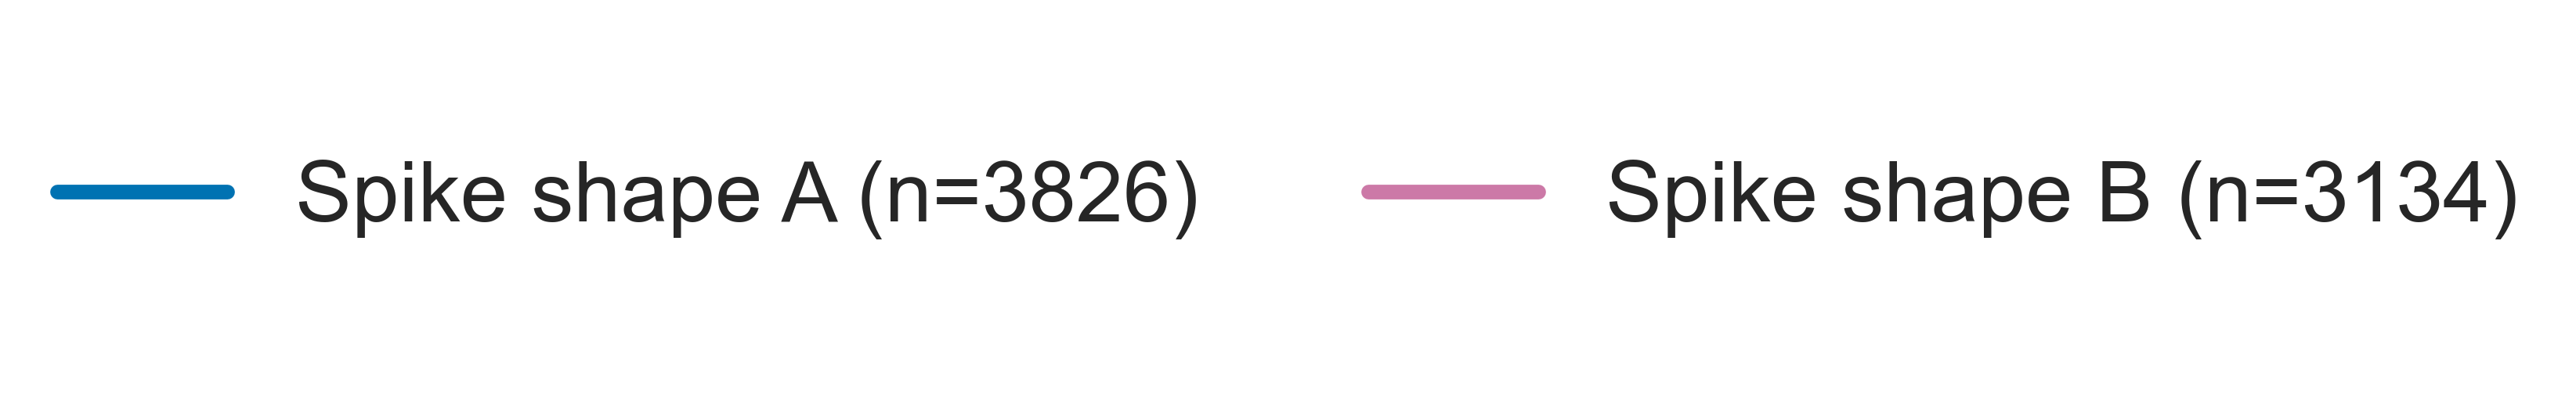

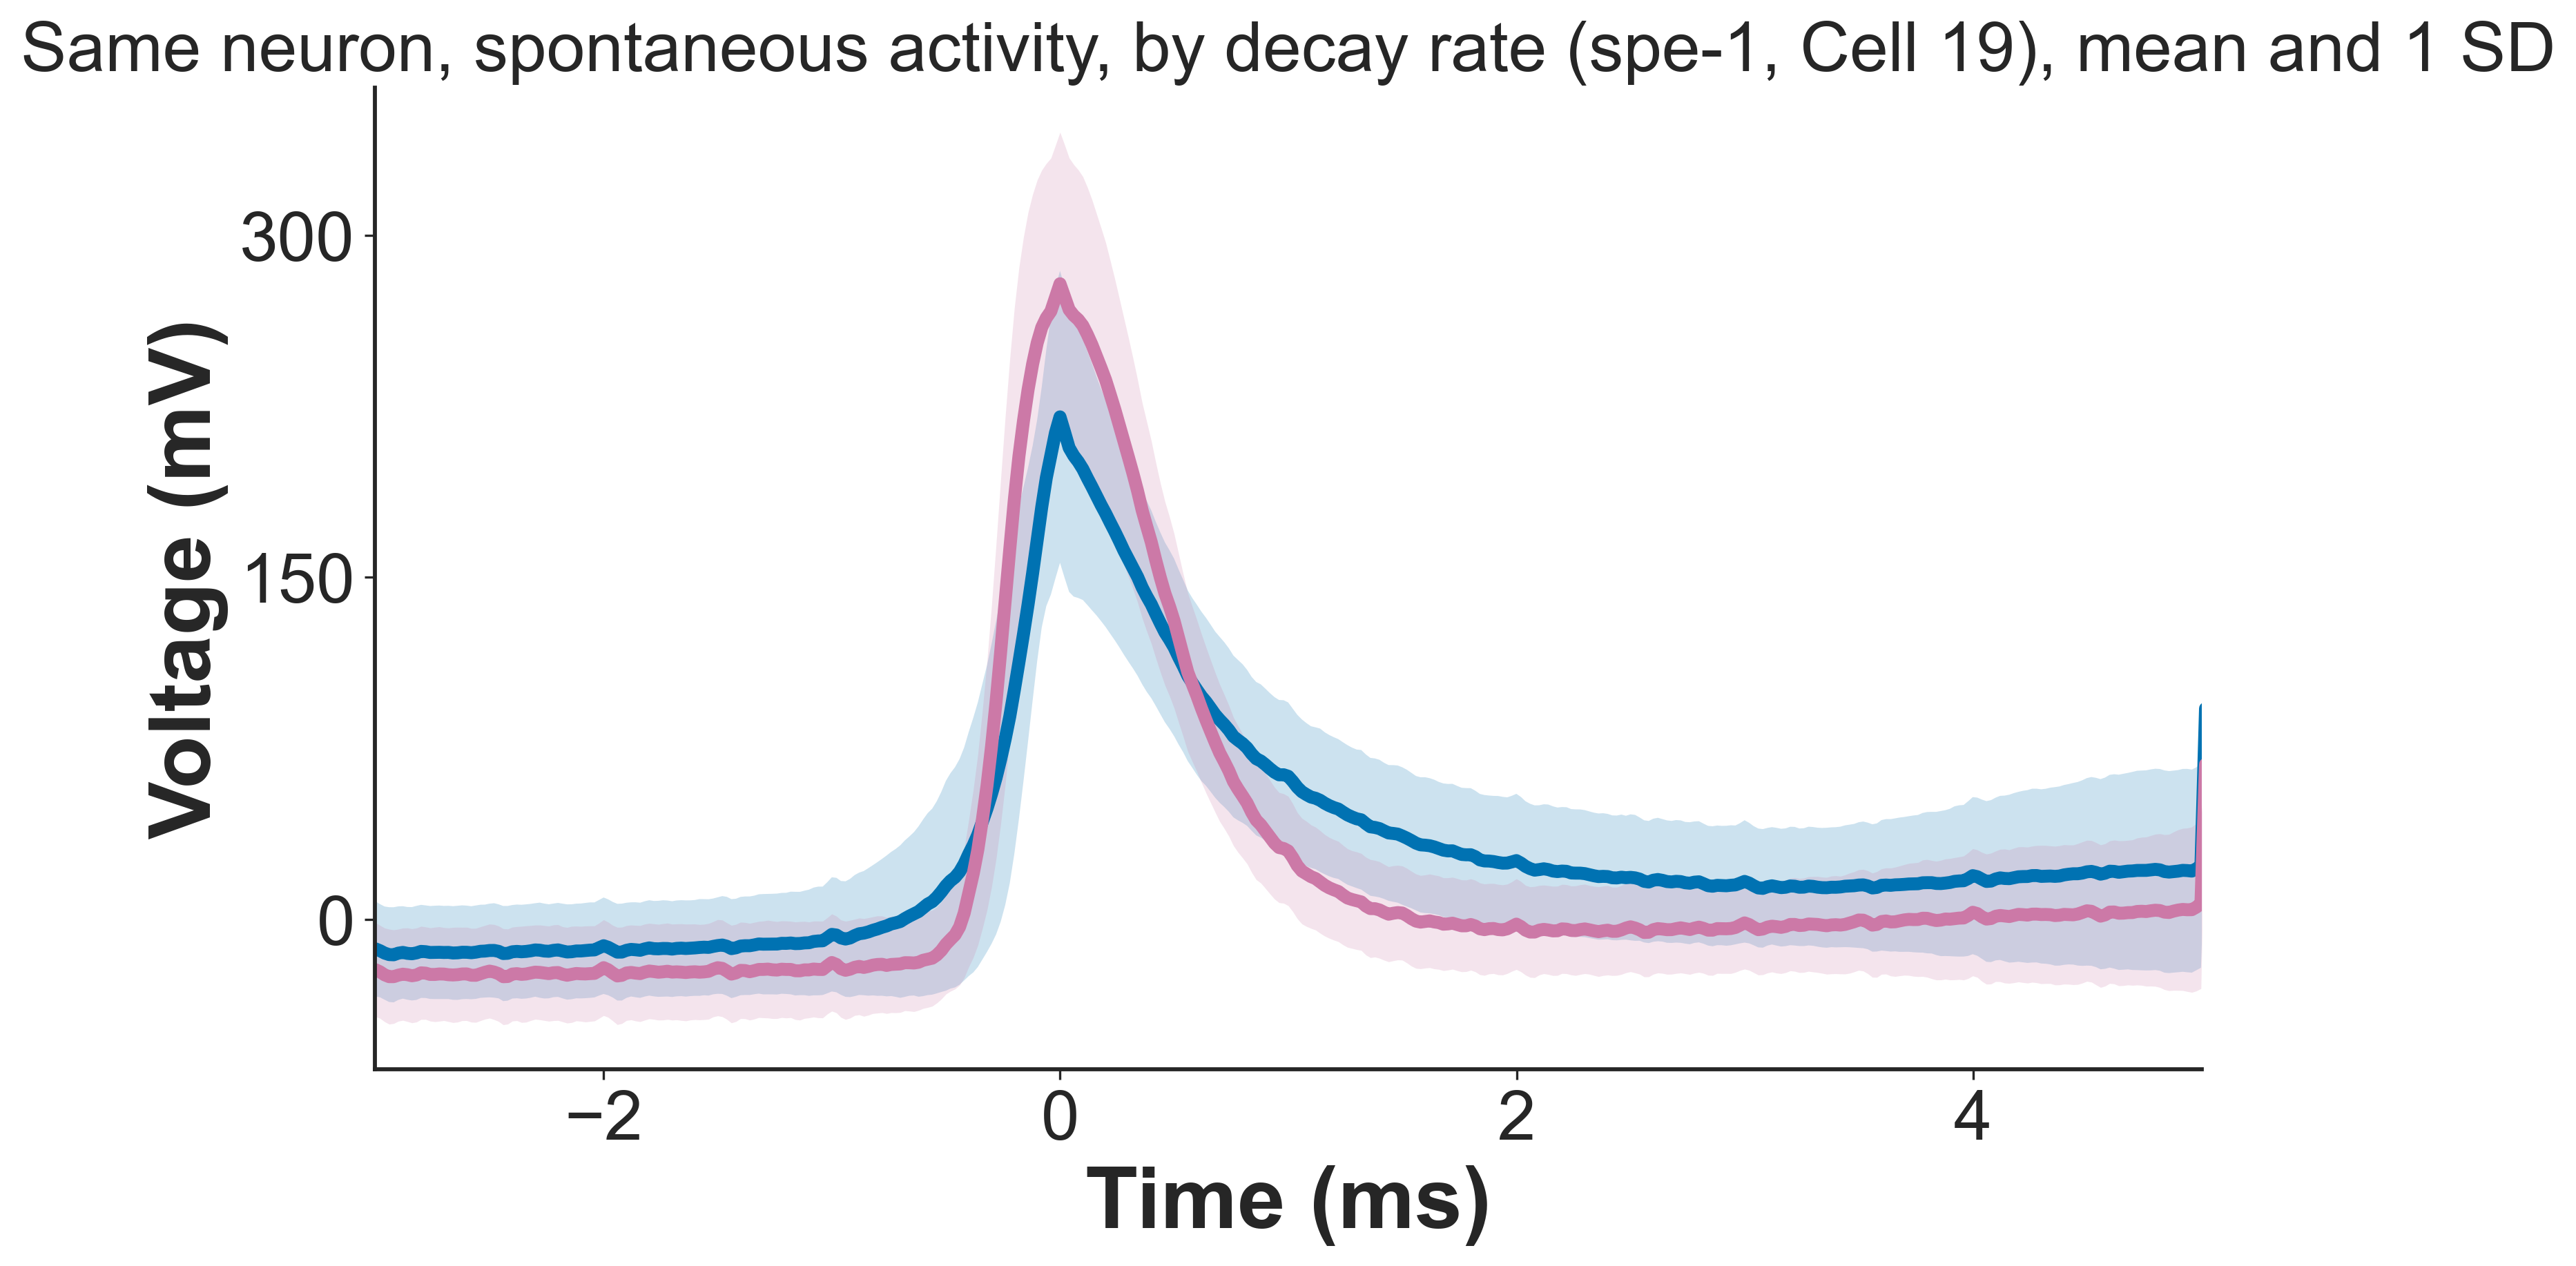

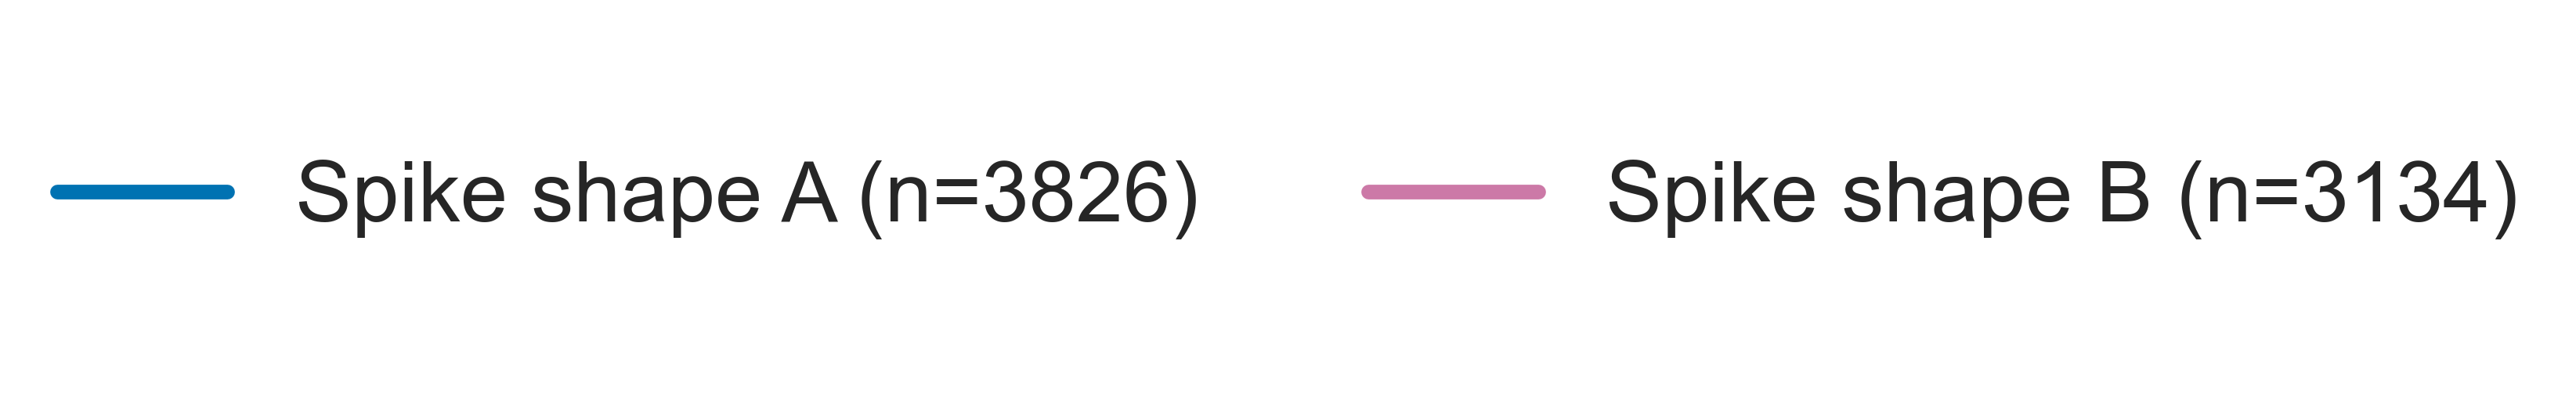

In [7]:
with open(os.path.join(CLUSTER_PKL_DIR, 'c19_cluster_waveforms.pkl'), 'rb') as f:
    c19_wf = pickle.load(f)['exp_lambda_cluster']

fs_c19 = config.DICT_PATCH_FS[19]
t_c19 = c19_wf['t_axis'] / fs_c19 * 1000.0

C19_COLORS = {'low': '#0072B2', 'high': '#CC79A7'}  # matches Fig 4B/C, Supp Fig 7-11 (2-group)
C19_LABELS = {'low': 'Spike shape A', 'high': 'Spike shape B'}

fig2b, ax2b = plt.subplots(figsize=(10, 6), constrained_layout=True)
for k in ['low', 'high']:
    m = c19_wf[k]['mean']
    s = c19_wf[k]['std']
    ax2b.fill_between(t_c19, m - s, m + s, color=C19_COLORS[k], alpha=0.2, lw=0)
    ax2b.plot(t_c19, m, color=C19_COLORS[k], lw=4.5, label=f"{C19_LABELS[k]} (n={c19_wf[k]['n']})")
ax2b.set_xlim(-3, 5)
ax2b.set_xlabel('Time (ms)')
ax2b.set_ylabel('Voltage (mV)')
ax2b.set_title('Same neuron, spontaneous activity, by decay rate (spe-1, Cell 19), mean and 1 SD')
style_press_ax(ax2b)


## Row 3, spe-1, Cell 3: waveform by surrounding LFP amplitude

Same idea as Fig. 4E-G: spike waveform shape predicts the amplitude of the local field
potential (LFP) around it. Cell 3 has the strongest individual-cell relationship in the
dataset (CV R² = 0.64 for pre-spike LFP amplitude), so it's the clearest illustration.

In [8]:
from spk_feat_cluster_analysis import peak_align_waveforms

LFP_COLORS = {'low': '#004488', 'high': '#BB5566'}  # Paul Tol high-contrast, distinct from
LFP_LABELS = {'low': 'Low LFP amplitude', 'high': 'High LFP amplitude'}  # every other color here


def load_spe1_lfp_raw(cell_num, force_rerun=False):
    """Fit `cell_num`, pairing each spike's raw waveform with its pre-spike LFP amplitude."""
    cache_path = os.path.join(CACHE_DIR, f'spe1_c{cell_num}_raw.pkl')
    if not force_rerun and os.path.exists(cache_path):
        with open(cache_path, 'rb') as f:
            return pickle.load(f)

    from spikewise.patch.fit import Spike
    patch_fs = config.DICT_PATCH_FS[cell_num]
    patch_filt = np.load(os.path.join(config.SPE1_DATA_ROOT, 'filt_patch_recordings', f'c{cell_num}_patch.npy'))

    sp = Spike(thresh_amp=2, window_length=(5., 5.), smooth_frac=.01)
    sp.fit(patch_filt, patch_fs, n_jobs=-1, flip_signal=False)
    sp.filter_features()

    # per-spike LFP trace, index-aligned to sp.spikes via spk_id (0..n-1)
    with open(os.path.join(config.SPE1_PICKLE_ROOT, 'simple_lfp_pickles', f'c{cell_num}_simple_lfp.pkl'), 'rb') as f:
        simple_lfp = pickle.load(f)

    n = min(len(sp.spikes), len(simple_lfp))
    pre_lfp_amp = np.full(n, np.nan)
    for i in range(n):
        t_bins = simple_lfp[i]['t_bins_s']
        mask = (t_bins >= -0.055) & (t_bins <= -0.005)  # pre-spike window, Methods: -55 to -5 ms
        if mask.any():
            pre_lfp_amp[i] = np.mean(simple_lfp[i]['lfp_mean'][mask])

    # Re-align each spike to its own peak at t=0 (same as the cluster-waveform pipeline
    # elsewhere) -- raw window_spike() extraction can leave a sample or two of jitter,
    # which is visible once you overlay many individual (non-averaged) traces.
    aligned = peak_align_waveforms(list(sp.spikes[:n]))

    raw = {
        'spikes': aligned,
        'pre_lfp_amp': pre_lfp_amp,
        'r_squared_ramp': sp.r_squared_ramp[:n],
        'r_squared_exp': sp.r_squared_exp[:n],
        'fs': patch_fs,
    }
    with open(cache_path, 'wb') as f:
        pickle.dump(raw, f)
    return raw


def get_lfp_groups(raw, lfp_pctl=(33, 67)):
    """Low/high pre-spike LFP amplitude masks, plus the time axis and quality score."""
    spikes = raw['spikes']
    pre_col = int(np.nanargmax(np.abs(spikes[0])))  # peak column is the same for every row
    t = (np.arange(spikes.shape[1]) - pre_col) / raw['fs'] * 1000.0
    quality = np.minimum(raw['r_squared_ramp'], raw['r_squared_exp'])
    pre_lfp_amp = raw['pre_lfp_amp']
    valid = ~np.isnan(pre_lfp_amp)
    lo_cut, hi_cut = np.percentile(pre_lfp_amp[valid], list(lfp_pctl))
    groups = {
        'low': valid & (pre_lfp_amp <= lo_cut),
        'high': valid & (pre_lfp_amp >= hi_cut),
    }
    return t, quality, groups


def _quality_filtered_idx(quality, group_mask, quality_pctl=QUALITY_PCTL):
    grp_idx = np.where(group_mask)[0]
    quality_cut = np.percentile(quality[grp_idx], quality_pctl)
    return grp_idx[quality[grp_idx] >= quality_cut]


def plot_lfp_all_spikes(raw, cell_num, quality_pctl=QUALITY_PCTL, lfp_pctl=(33, 67)):
    """Every quality-passing spike overlaid (low alpha) plus the group mean on top."""
    spikes = raw['spikes']
    t, quality, groups = get_lfp_groups(raw, lfp_pctl)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True, constrained_layout=True)
    for ax, grp in zip(axes, ['low', 'high']):
        idx = _quality_filtered_idx(quality, groups[grp], quality_pctl)
        for i in idx:
            ax.plot(t, spikes[i], color=LFP_COLORS[grp], lw=0.8, alpha=0.08)
        ax.plot(t, np.nanmean(spikes[idx], axis=0), color=LFP_COLORS[grp], lw=4)
        ax.set_xlim(-3, 5)
        ax.set_xlabel('Time (ms)')
        ax.set_title(f"{LFP_LABELS[grp]} (n={len(idx)})", fontsize=17)
        style_press_ax(ax, legend=False)
    axes[0].set_ylabel('Voltage (mV)')
    fig.suptitle(f'Same neuron, all spikes by surrounding LFP amplitude (spe-1, Cell {cell_num})',
                 fontsize=17, y=1.05)
    return fig


def plot_lfp_shaded(raw, cell_num, quality_pctl=QUALITY_PCTL, lfp_pctl=(33, 67)):
    """Group mean with a shaded +/-1 SD band, same convention as the other rows above."""
    spikes = raw['spikes']
    t, quality, groups = get_lfp_groups(raw, lfp_pctl)

    fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
    for grp in ['low', 'high']:
        idx = _quality_filtered_idx(quality, groups[grp], quality_pctl)
        wf = spikes[idx]
        m = np.nanmean(wf, axis=0)
        s = np.nanstd(wf, axis=0)
        ax.fill_between(t, m - s, m + s, color=LFP_COLORS[grp], alpha=0.2, lw=0)
        ax.plot(t, m, color=LFP_COLORS[grp], lw=4.5, label=f'{LFP_LABELS[grp]} (n={len(idx)})')
    ax.set_xlim(-3, 5)
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Voltage (mV)')
    ax.set_title(f'Same neuron, by surrounding LFP amplitude (spe-1, Cell {cell_num}), mean and 1 SD')
    style_press_ax(ax)
    return fig

/var/folders/rr/tk8wmt7x4xlgzgmcy768y1rm0000gn/T/ipykernel_19226/2242828366.py:103: RuntimeWarning: Mean of empty slice
  m = np.nanmean(wf, axis=0)
/Users/blancamartin/opt/anaconda3/envs/spikewise/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/var/folders/rr/tk8wmt7x4xlgzgmcy768y1rm0000gn/T/ipykernel_19226/2242828366.py:83: RuntimeWarning: Mean of empty slice
  ax.plot(t, np.nanmean(spikes[idx], axis=0), color=LFP_COLORS[grp], lw=4)


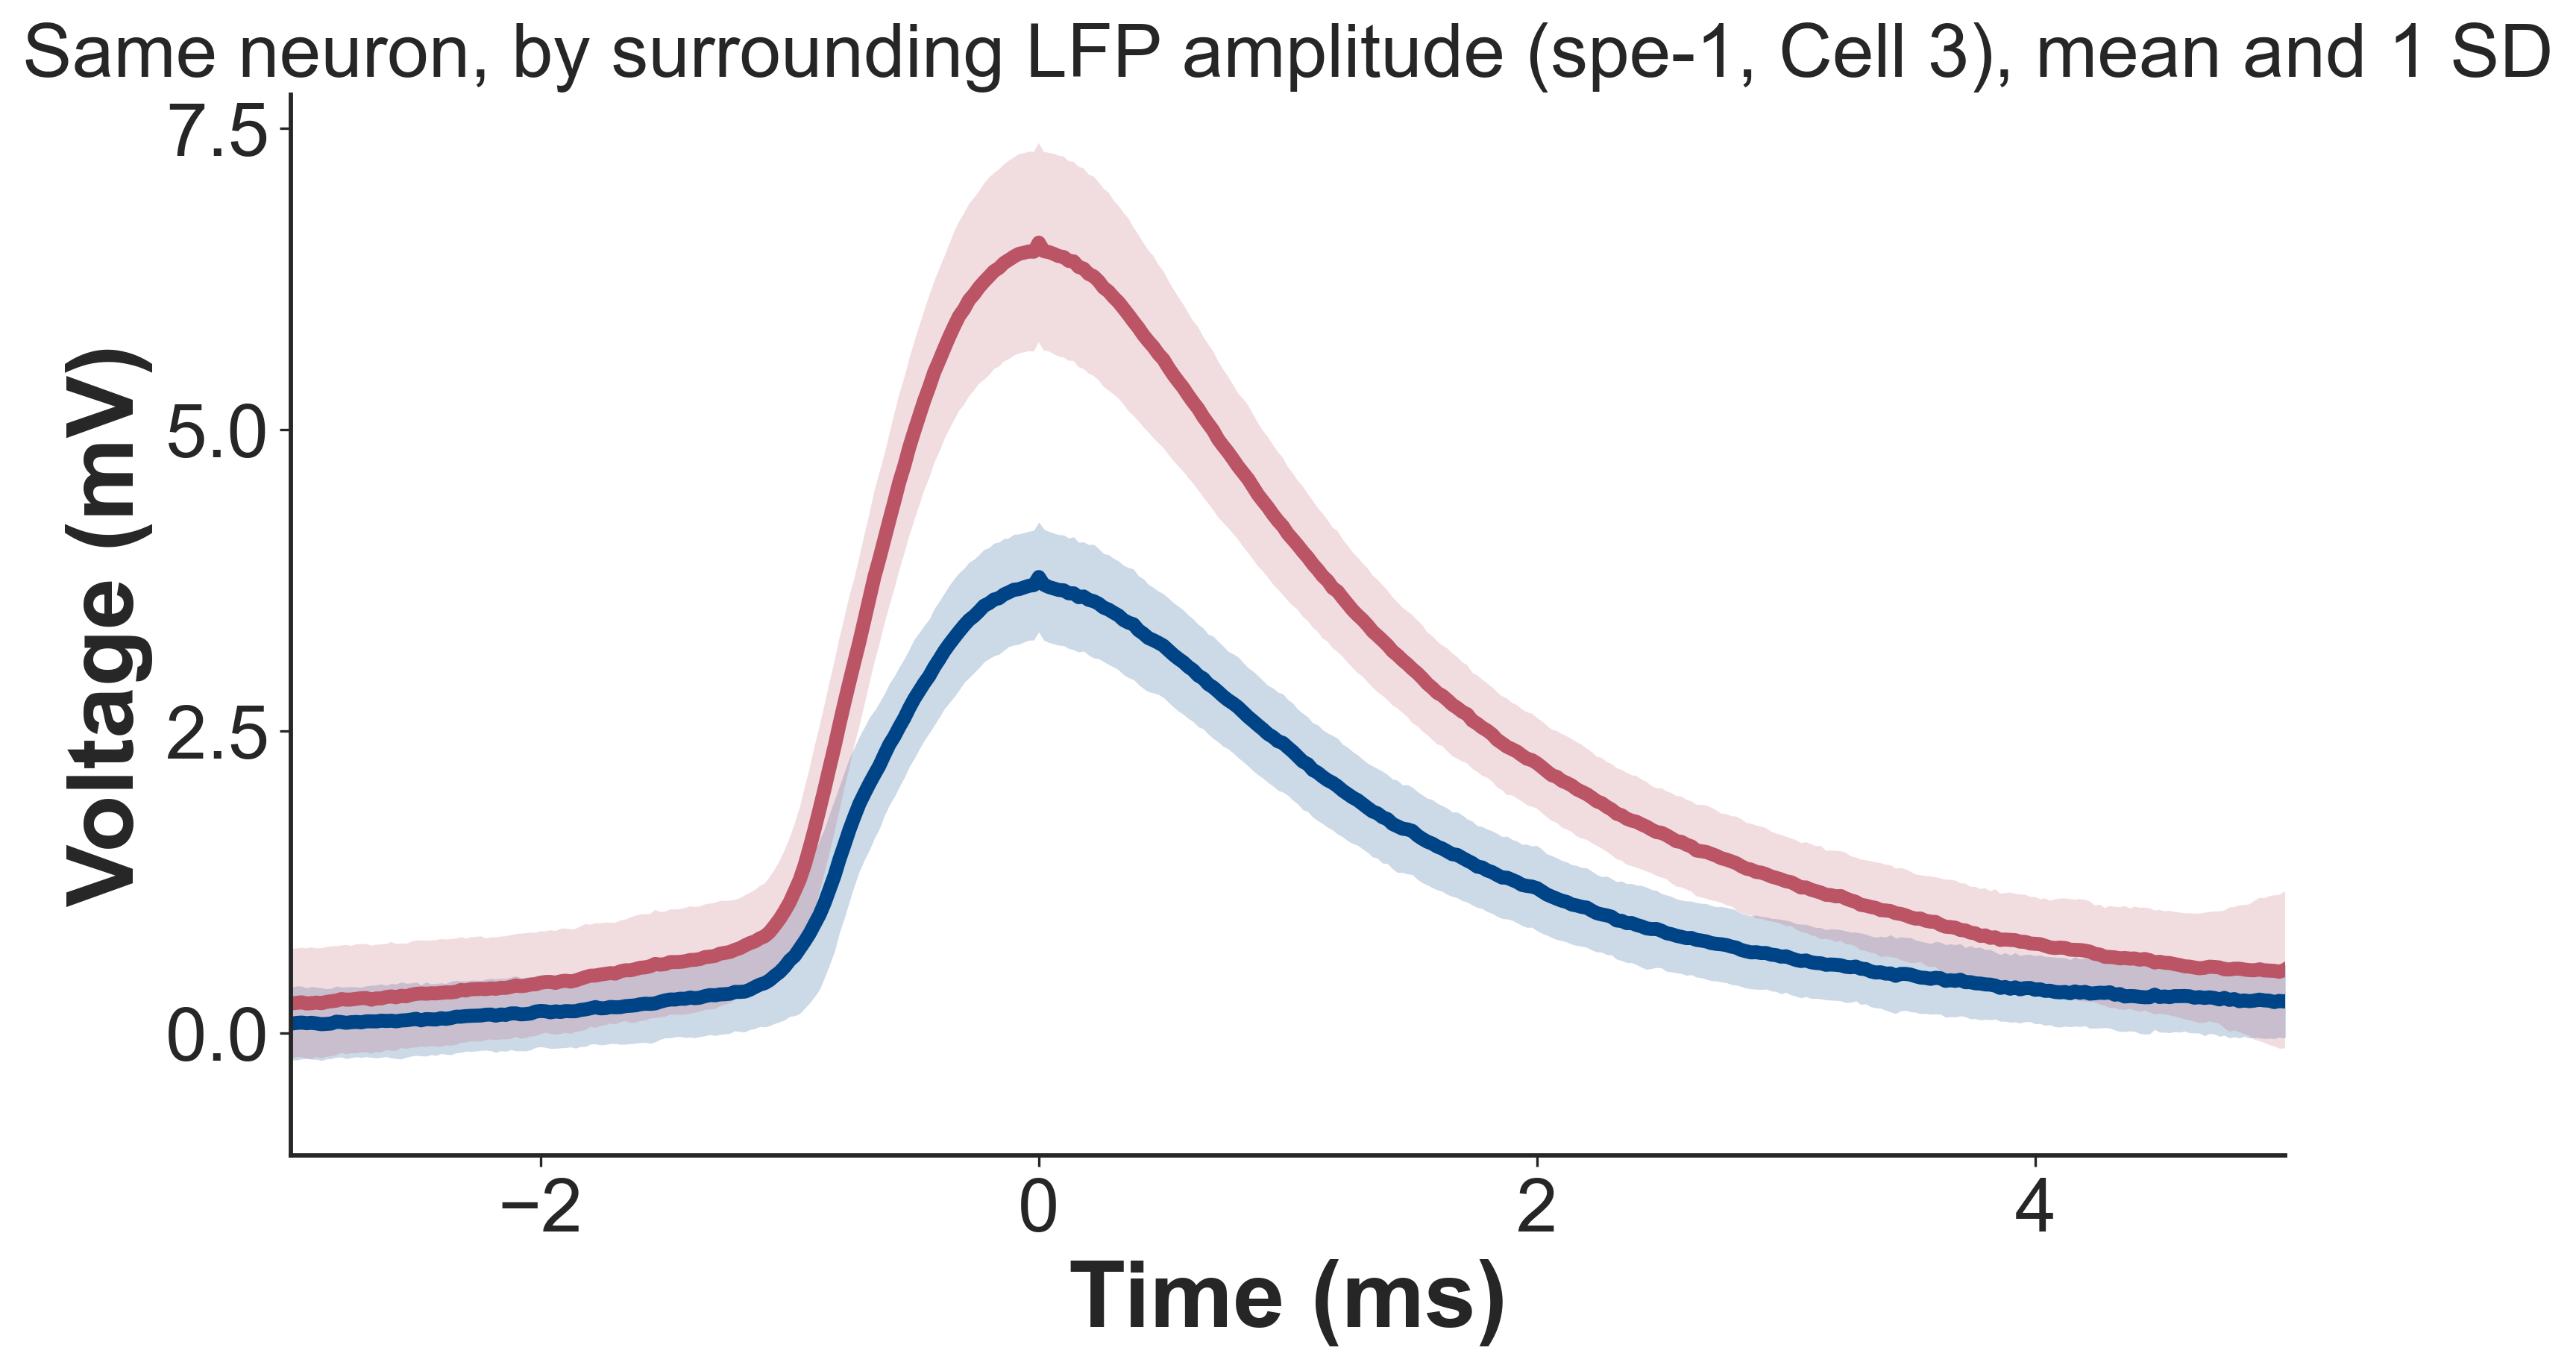

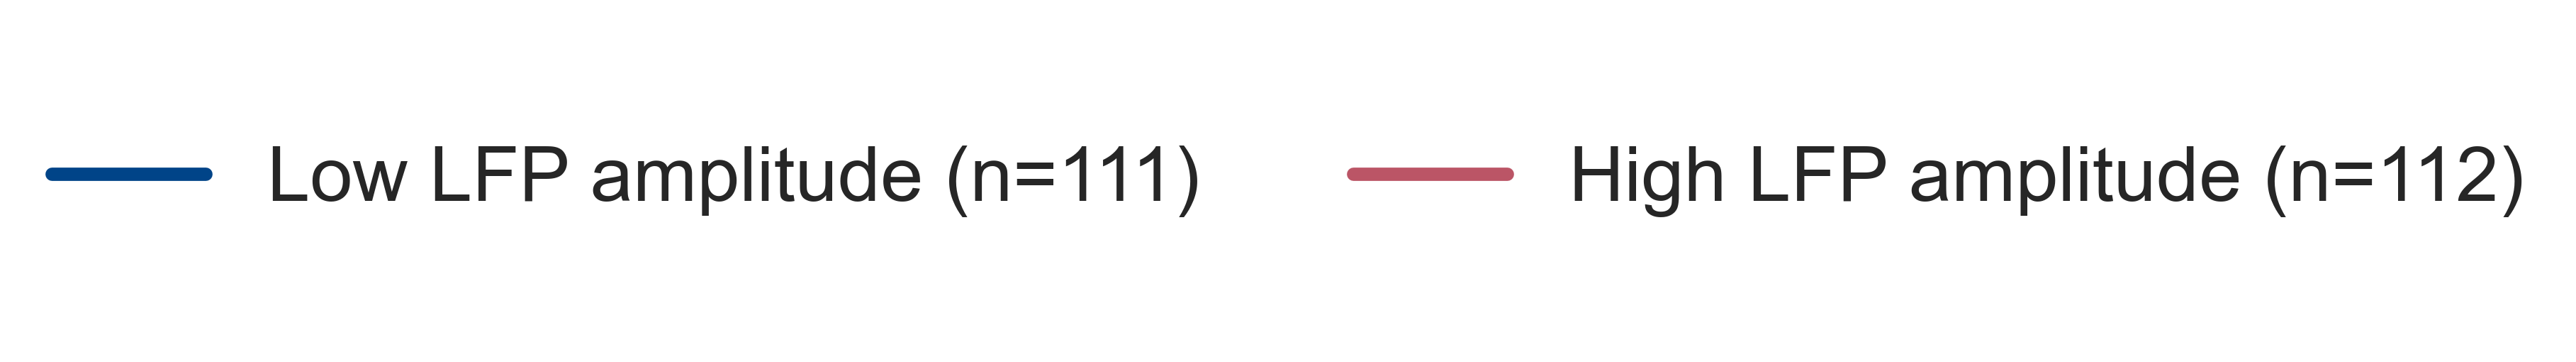

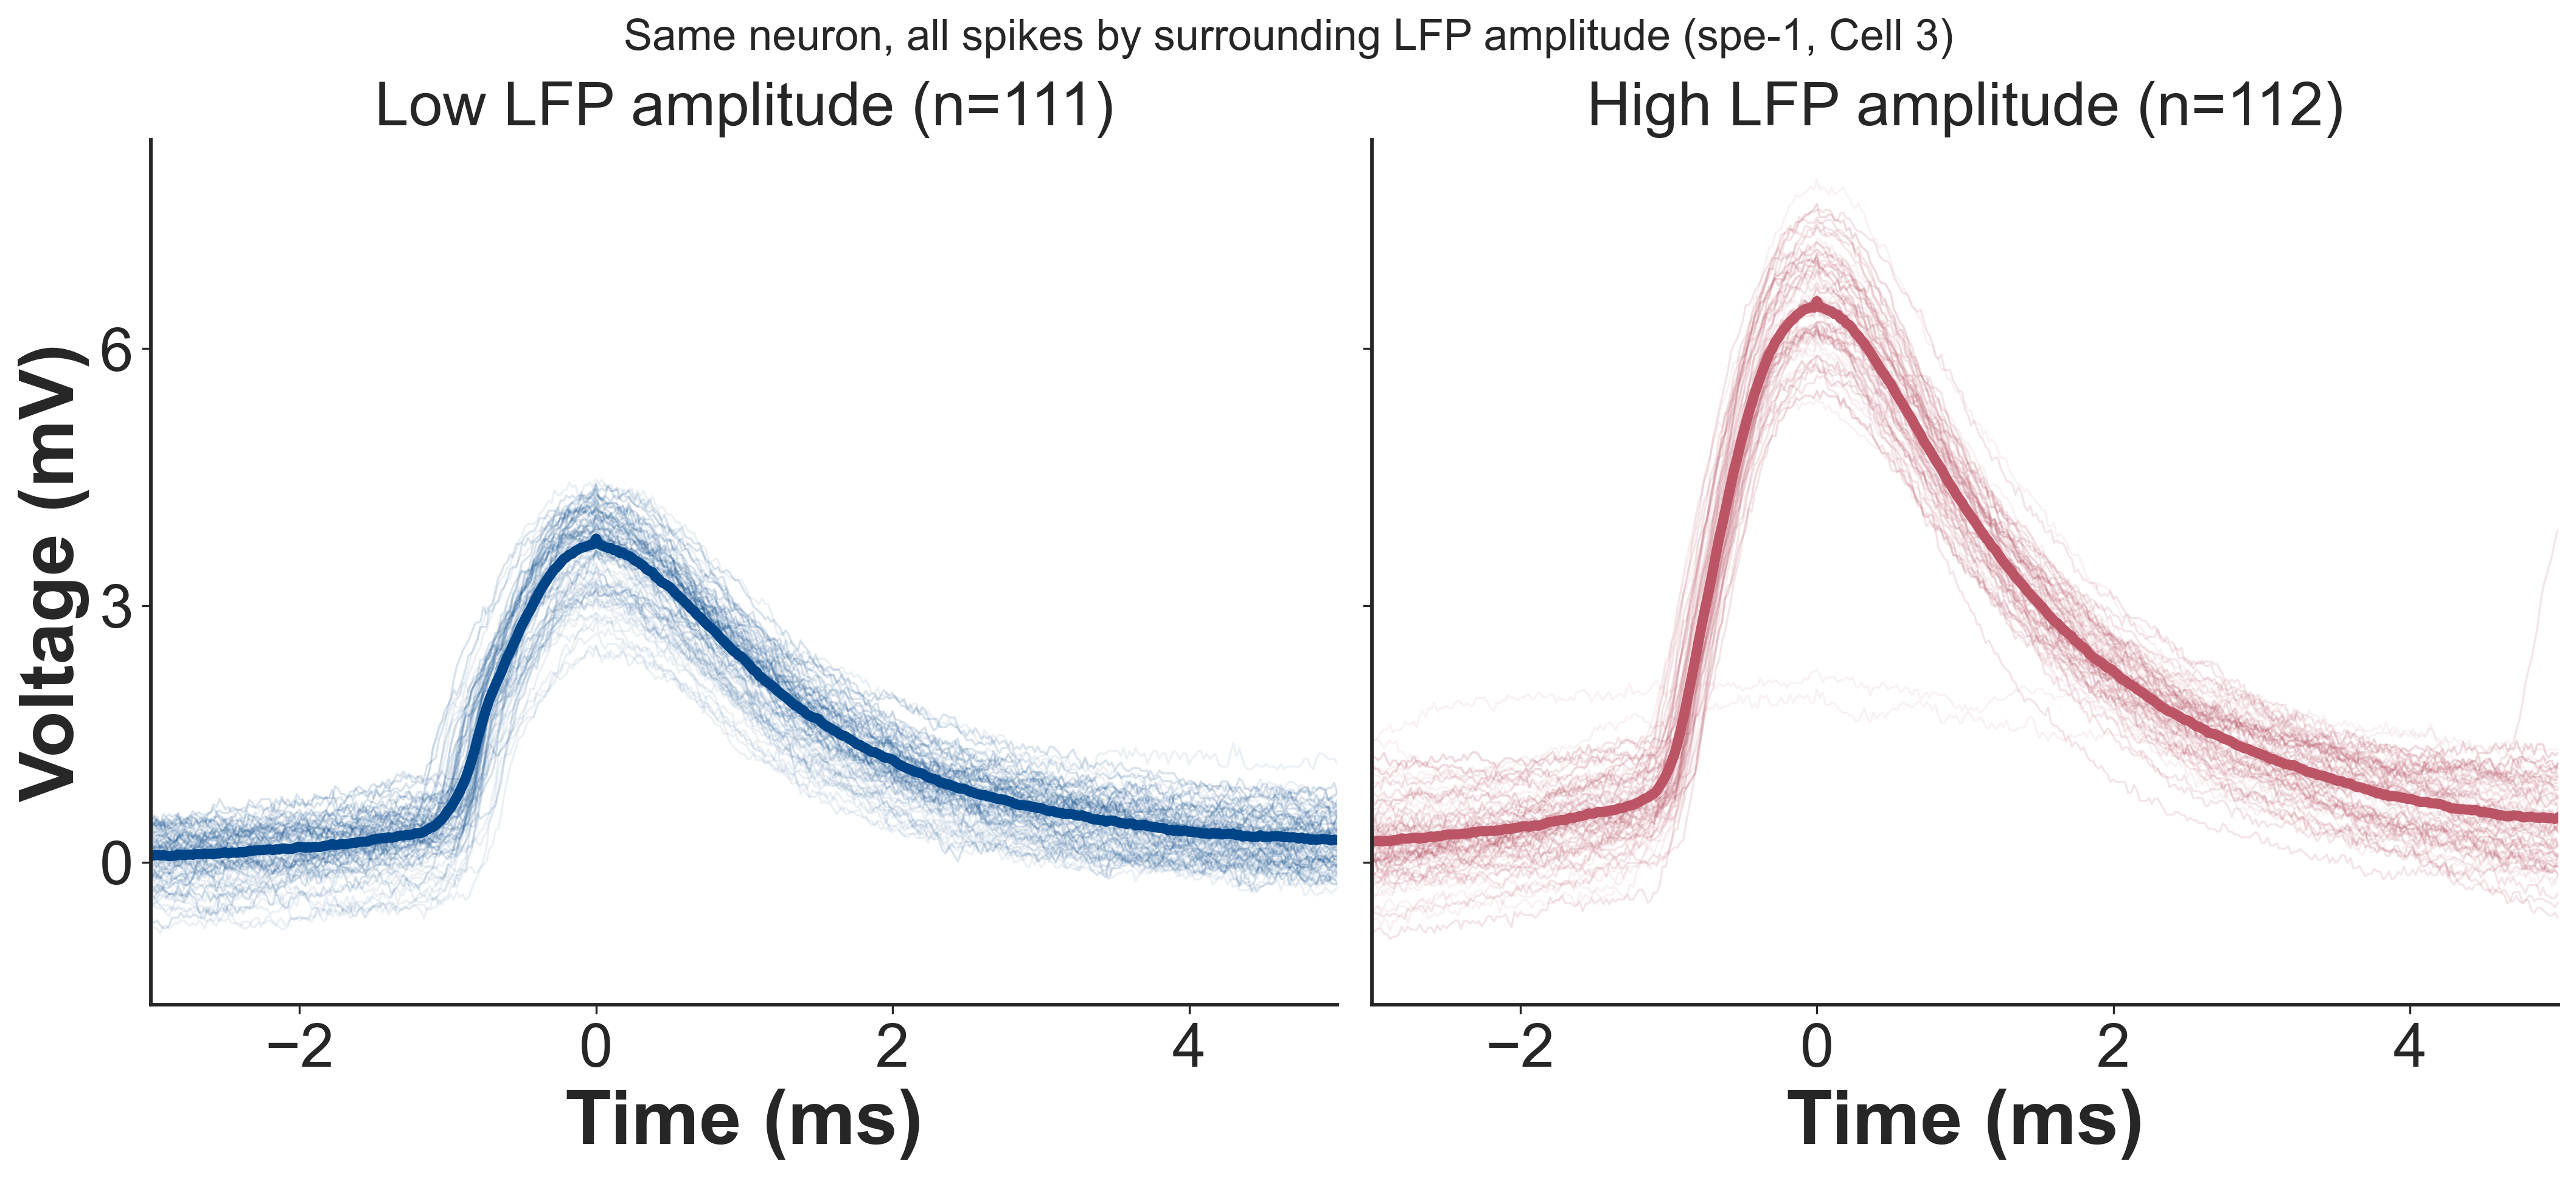

In [9]:
c3_raw = load_spe1_lfp_raw(3)
_ = plot_lfp_shaded(c3_raw, 3)
_ = plot_lfp_all_spikes(c3_raw, 3)

### Cell 1 (second-best LFP-amplitude relationship, CV R^2 = 0.43)

/var/folders/rr/tk8wmt7x4xlgzgmcy768y1rm0000gn/T/ipykernel_19226/2242828366.py:103: RuntimeWarning: Mean of empty slice
  m = np.nanmean(wf, axis=0)
/var/folders/rr/tk8wmt7x4xlgzgmcy768y1rm0000gn/T/ipykernel_19226/2242828366.py:83: RuntimeWarning: Mean of empty slice
  ax.plot(t, np.nanmean(spikes[idx], axis=0), color=LFP_COLORS[grp], lw=4)


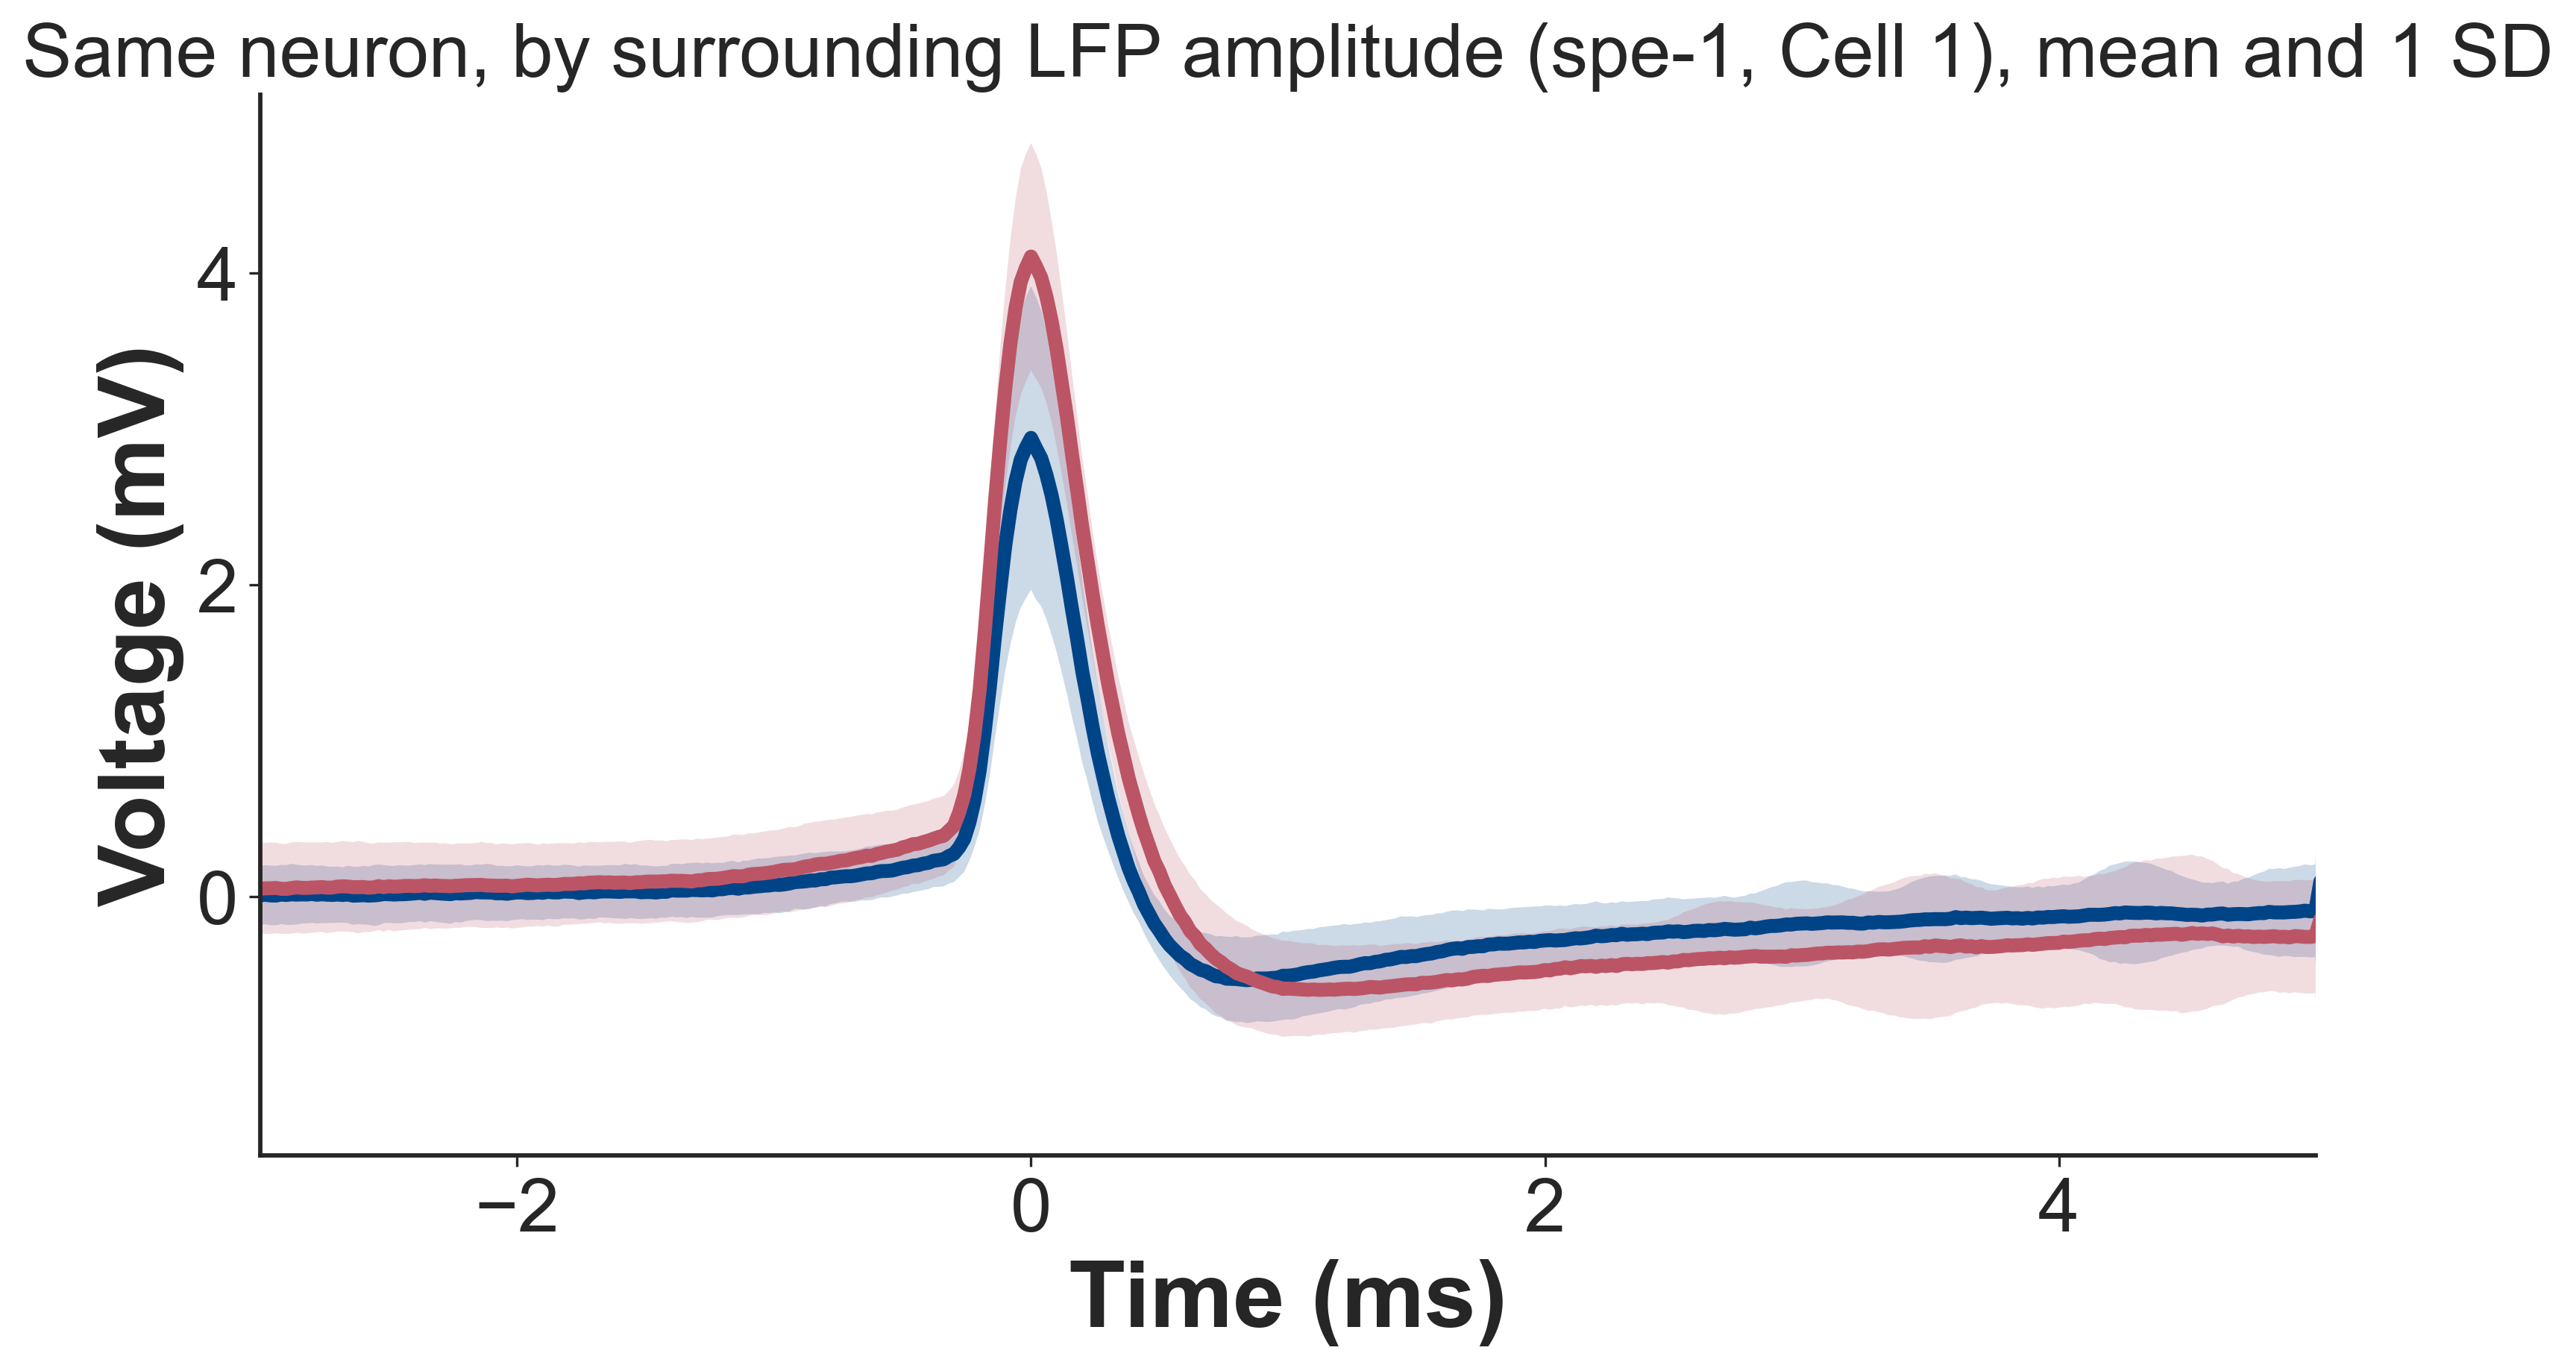

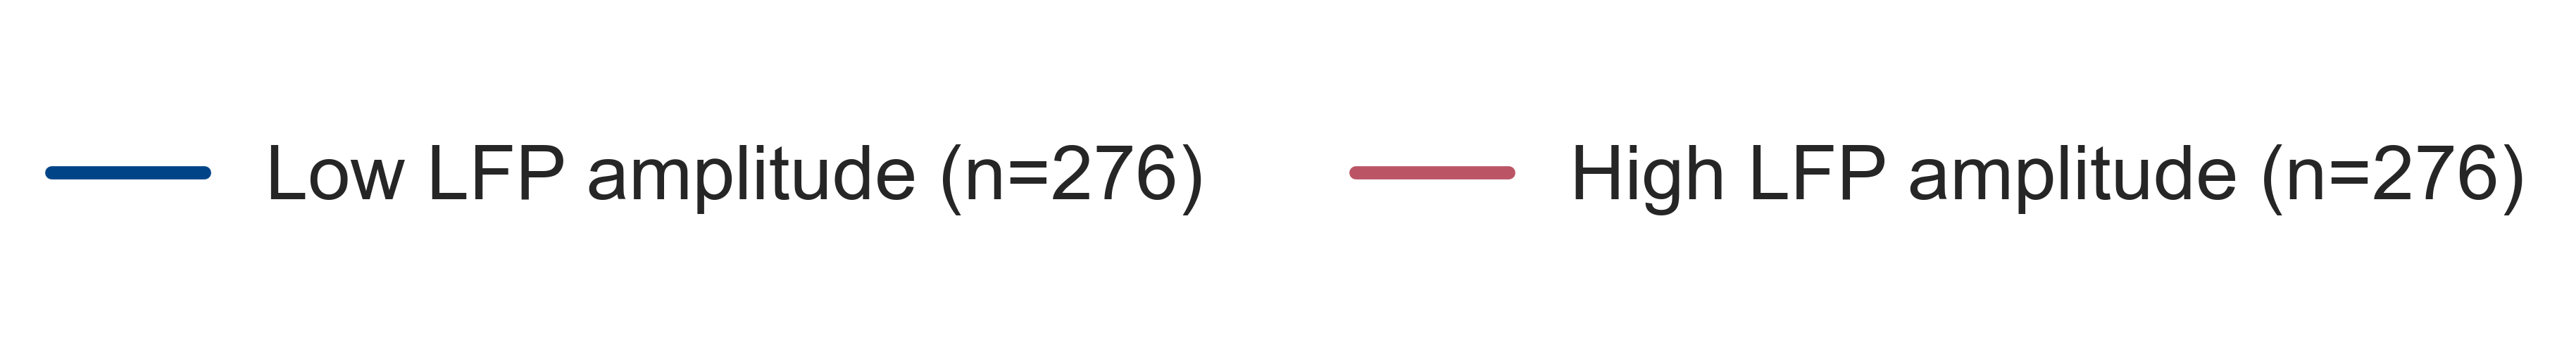

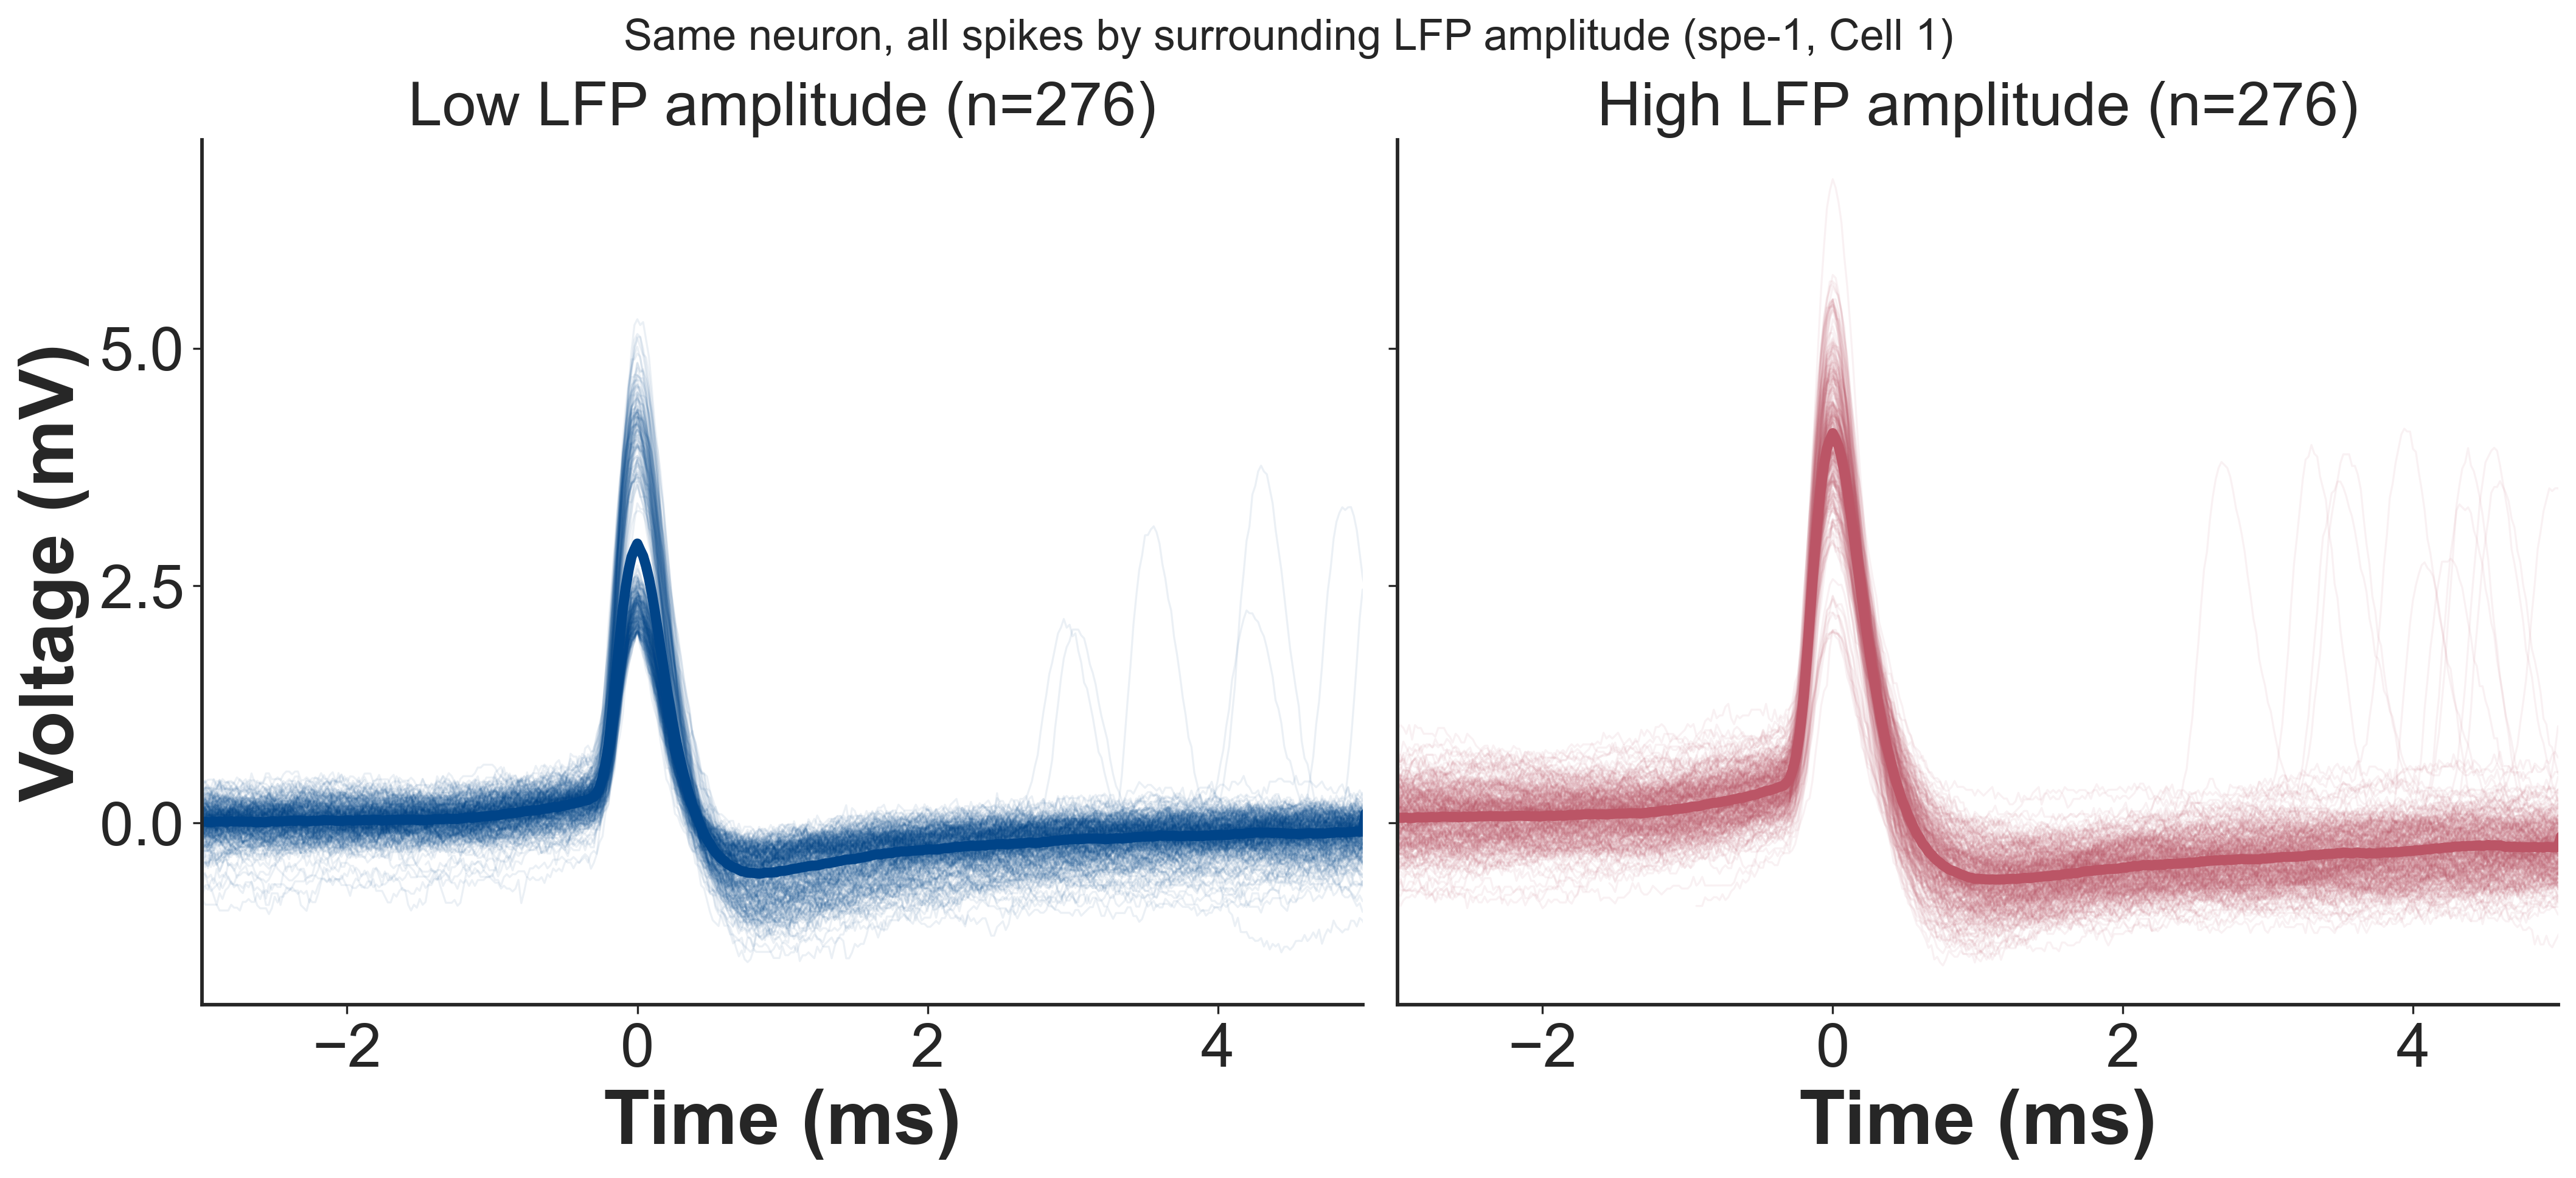

In [10]:
c1_raw = load_spe1_lfp_raw(1)
_ = plot_lfp_shaded(c1_raw, 1)
_ = plot_lfp_all_spikes(c1_raw, 1)